In [66]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('AIRI-Institute/gena-lm-bert-base-fly')
print(tokenizer.pad_token_id)
print(tokenizer.eos_token_id)
print(tokenizer.bos_token_id)
print(tokenizer.cls_token_id)
print(tokenizer.mask_token_id)
print(tokenizer.sep_token_id)
print(tokenizer.unk_token_id)
print(tokenizer.vocab_size)

3
None
None
1
4
2
0
32000


In [18]:
import pandas as pd

df = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/decay/output/predict/token_shuffle_analysis.csv')
df = df[~df['original_token'].isin([1,2])]
df


,position,original_token,new_token,prediction,label,is_original,pred_change
0,-1,-1,-1,5.287418,5.141022,True,NaN
32000,1,4292,0,5.358575,5.141022,False,0.071157
32001,1,4292,1,5.334247,5.141022,False,0.046828
32002,1,4292,2,5.341848,5.141022,False,0.054430
32003,1,4292,3,5.454692,5.141022,False,0.167274
...,...,...,...,...,...,...,...
991965,30,375,31995,5.175980,5.141022,False,-0.111439
991966,30,375,31996,5.226956,5.141022,False,-0.060462
991967,30,375,31997,5.231480,5.141022,False,-0.055939
991968,30,375,31998,5.303826,5.141022,False,0.016408


In [28]:
import pickle
import os
try:
    os.chdir('scripts')
    print(os.getcwd())
    from myShap import Explainer
    from myShap.ferret_extras import BaseExplainer, Explanation
    os.chdir('..')
    print(os.getcwd())
    importances = pickle.load(open('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/decay/output/importance/test_shap.pkl', 'rb')) 
except:
    os.chdir('../../scripts')
    print(os.getcwd())
    from myShap import Explainer
    from myShap.ferret_extras import BaseExplainer, Explanation
    os.chdir('..')
    print(os.getcwd())
    importances = pickle.load(open('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/decay/output/importance/test_shap.pkl', 'rb')) 

scores = None
for imp in importances:
    if imp.actual == round(df.iloc[0]['label'],2):
        scores = imp.scores.flatten().tolist()
        print(imp)

/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/decay/scripts
/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/decay
Explanation(id='FBtr0332581', actual=5.14, prediction=5.29, tokens=['', 'TTATATTG', 'TTTTC', 'ATTTAC', 'TGTTGC', 'TTCAAGC', 'AGGCG', 'AATGAACC', 'TGGAAC', 'AGAC', 'TCCTCC', 'TGTAA', 'TGCGC', 'ACAGC', 'AACCGCC', 'TGAGATTC', 'TCGC', 'AGTAGCC', 'ACGC', 'AAC', '[SEP]', 'ACC', 'AATATTGC', 'TTGCCC', 'AACTTAA', 'ATATGTATT', 'AAGAAATT', 'AAAGACC', 'AGTGTTTG', 'AATAC', 'TTTTGG', ''], scores=array([[5.59670227e-07],
       [2.91136671e-02],
       [2.00301993e-02],
       [1.46980978e-02],
       [3.06564414e-02],
       [3.46346440e-02],
       [4.36456478e-02],
       [1.93977187e-02],
       [1.92671689e-02],
       [5.78813025e-02],
       [3.84200163e-02],
       [5.22994282e-02],
       [4.61361664e-02],
       [3.33004171e-02],
       [3.38955264e-02],
       [4.48379488e-02],
       [3.22986973e-02],
       [2.91336461e-02],
       [3.83270358e-02],
       [2.71

In [16]:
df['original_token'].unique()

array([   -1,  4292,   100,   386,   687,  1313,   852,  5349,   600,
          78,   367,   147,  1173,   219, 12563,  4720,   341,  2022,
         319,    42,    32,  4895,   399,  5232,  7141,  3450,  2283,
        6277,   226,   375])

In [17]:
print(df[df['new_token'] == 0]['pred_change'].abs().mean())
df[df['new_token'] == 0]

0.035836022475670075


,position,original_token,new_token,prediction,label,is_original,pred_change
32000,1,4292,0,5.358575,5.141022,False,0.071157
63999,2,100,0,5.352506,5.141022,False,0.065087
95998,3,386,0,5.351457,5.141022,False,0.064038
127997,4,687,0,5.296326,5.141022,False,0.008907
159996,5,1313,0,5.359595,5.141022,False,0.072177
191995,6,852,0,5.274951,5.141022,False,-0.012467
223994,7,5349,0,5.303155,5.141022,False,0.015737
255993,8,600,0,5.316814,5.141022,False,0.029396
287992,9,78,0,5.281003,5.141022,False,-0.006415
319991,10,367,0,5.335364,5.141022,False,0.047945


In [8]:
print(df[df['new_token'] == 4]['pred_change'].abs().mean())
df[(df['new_token'] == 4) | (df['position'] == -1)]

0.06281957955195983


,position,original_token,new_token,prediction,label,is_original,pred_change
0,-1,-1,-1,5.287418,5.141022,True,NaN
32004,1,4292,4,5.268937,5.141022,False,-0.018481
64003,2,100,4,5.267597,5.141022,False,-0.019821
96002,3,386,4,5.282209,5.141022,False,-0.005209
128001,4,687,4,5.219994,5.141022,False,-0.067424
160000,5,1313,4,5.281097,5.141022,False,-0.006321
191999,6,852,4,5.187417,5.141022,False,-0.100001
223998,7,5349,4,5.221779,5.141022,False,-0.065639
255997,8,600,4,5.228817,5.141022,False,-0.058601
287996,9,78,4,5.208355,5.141022,False,-0.079064


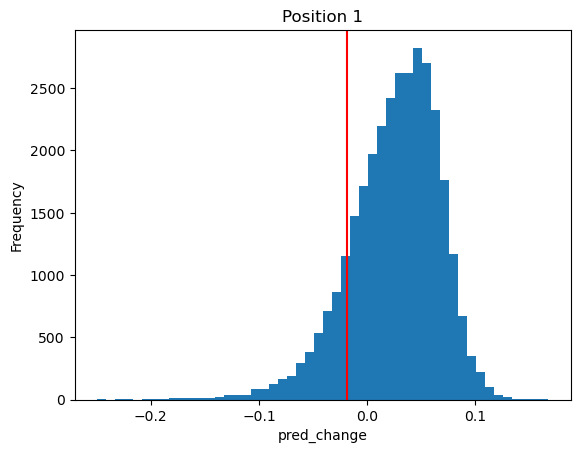

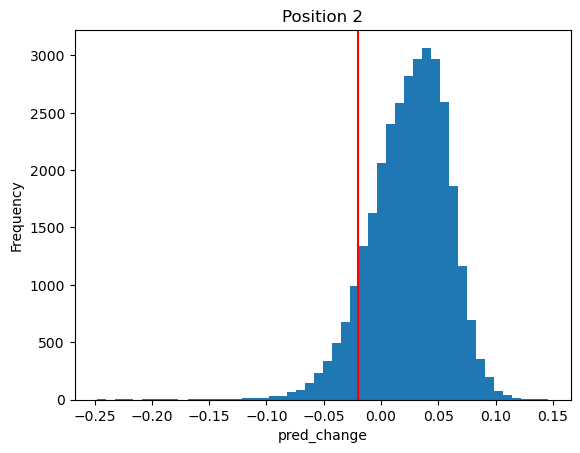

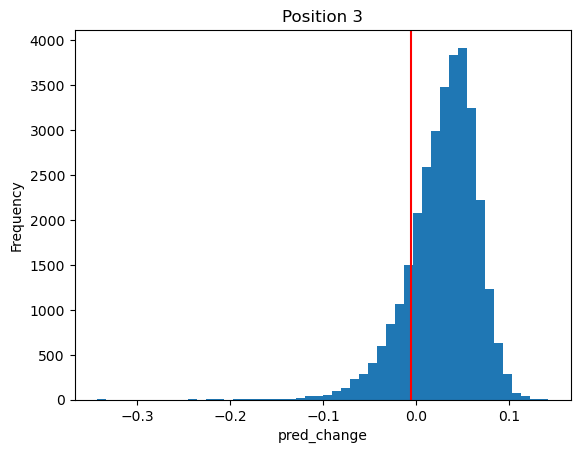

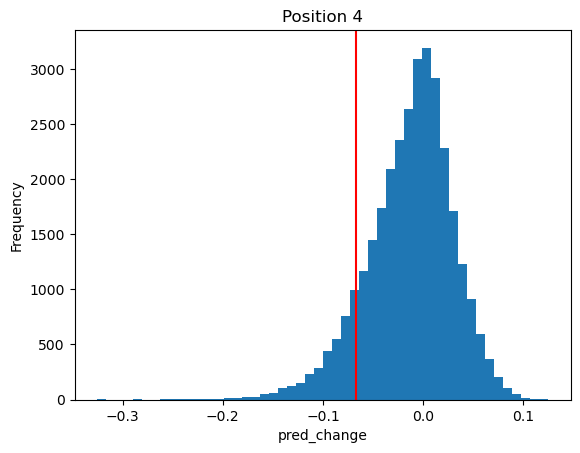

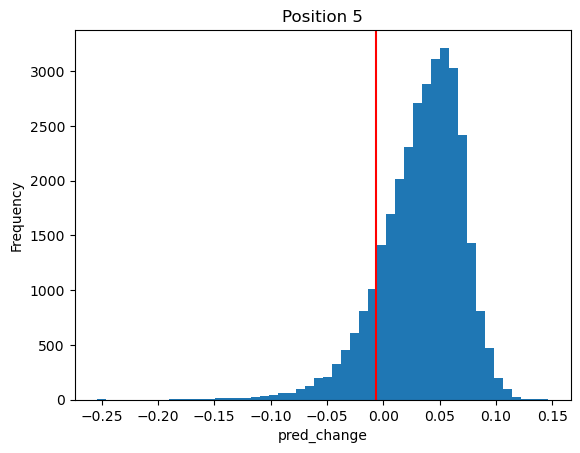

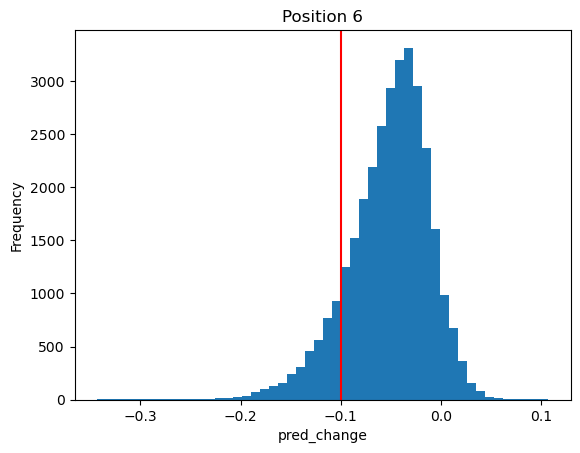

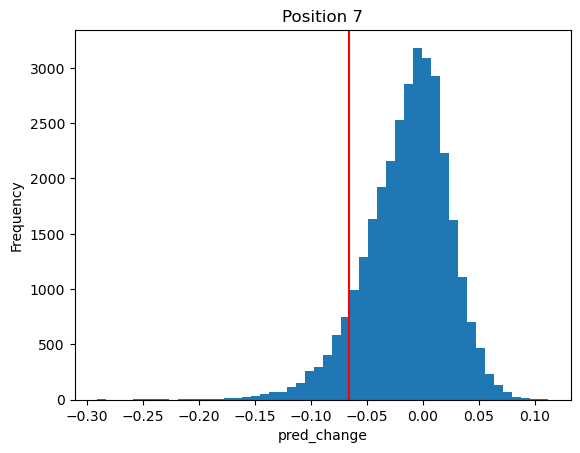

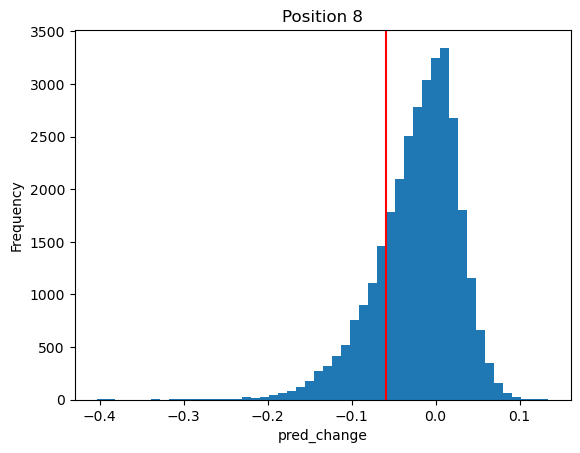

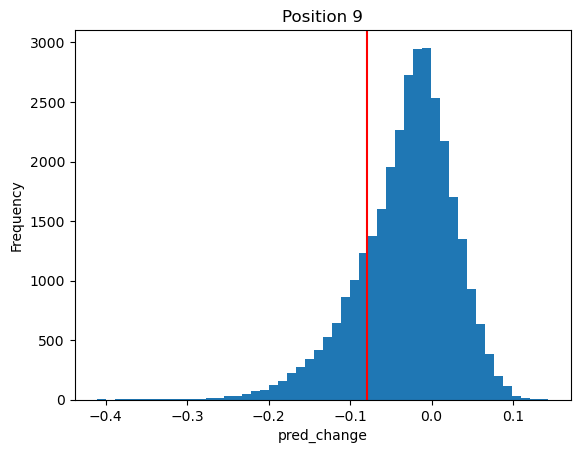

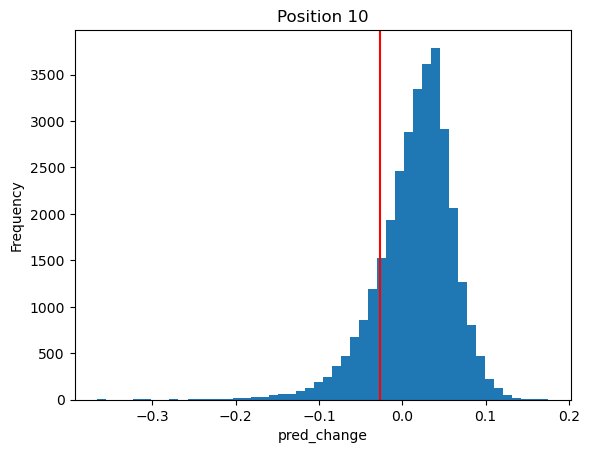

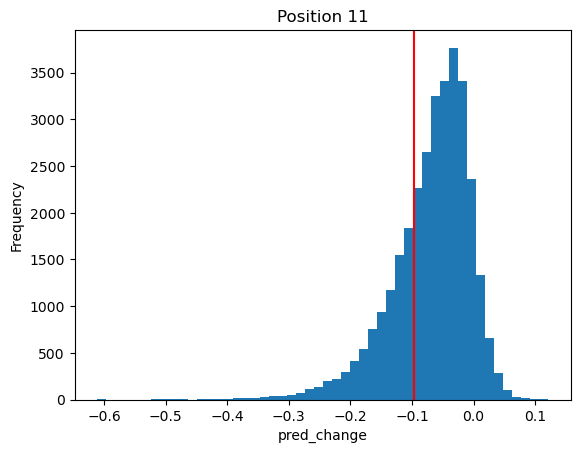

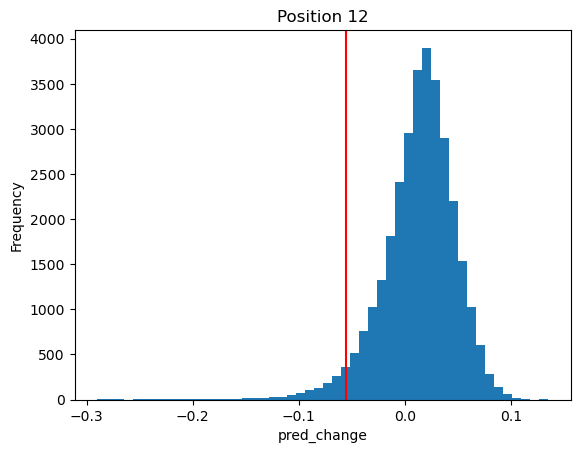

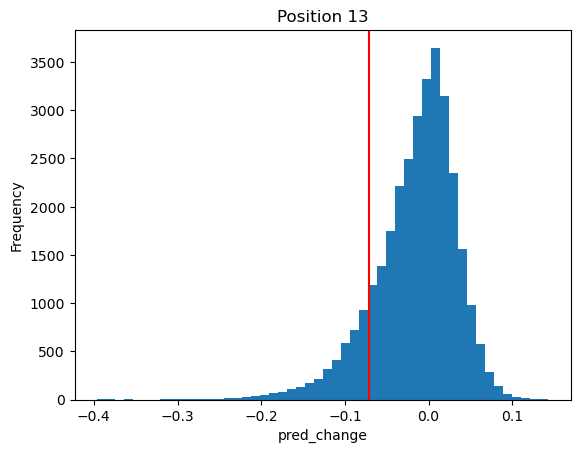

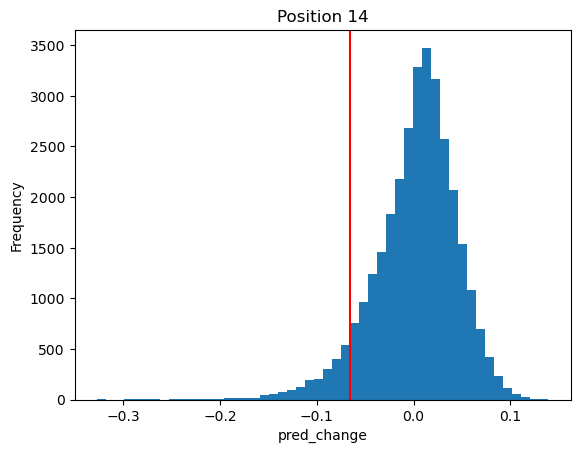

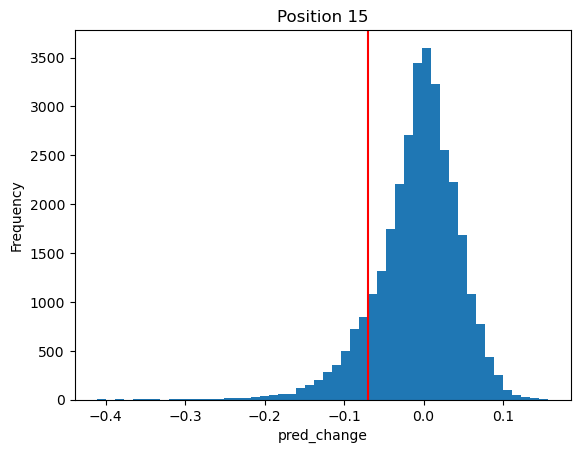

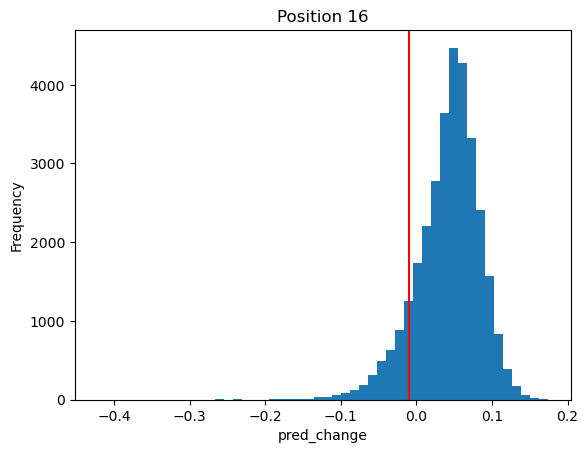

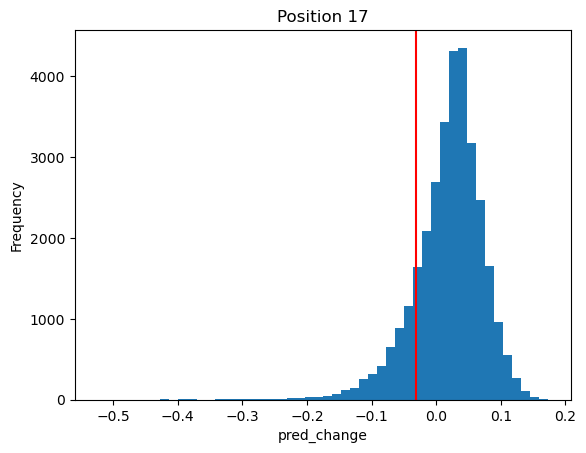

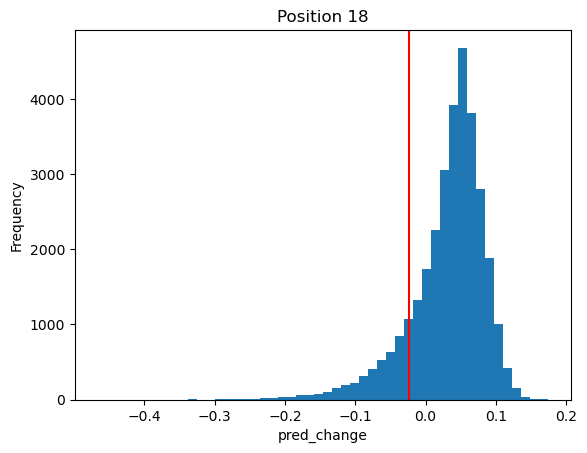

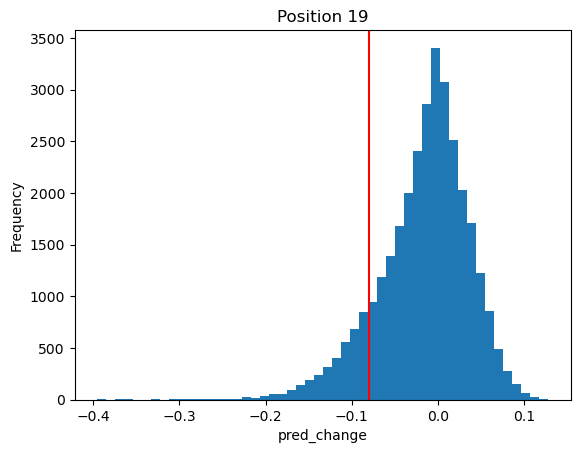

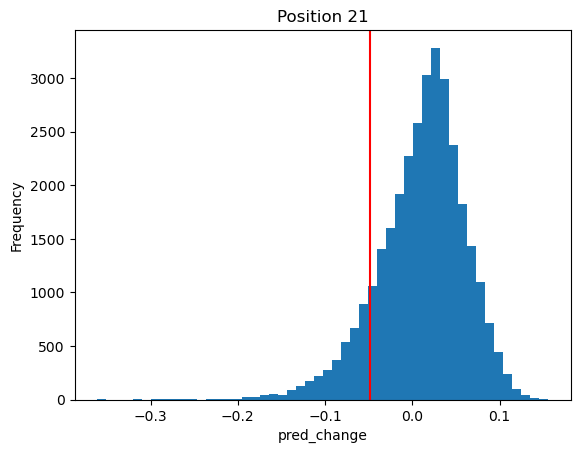

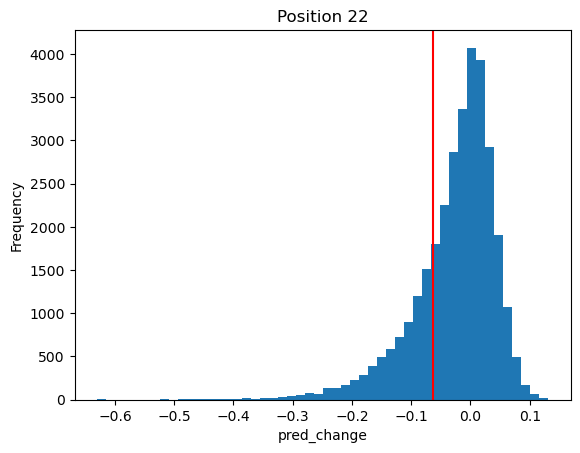

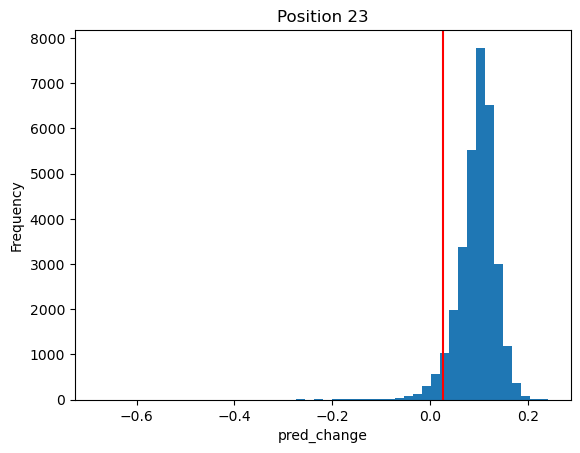

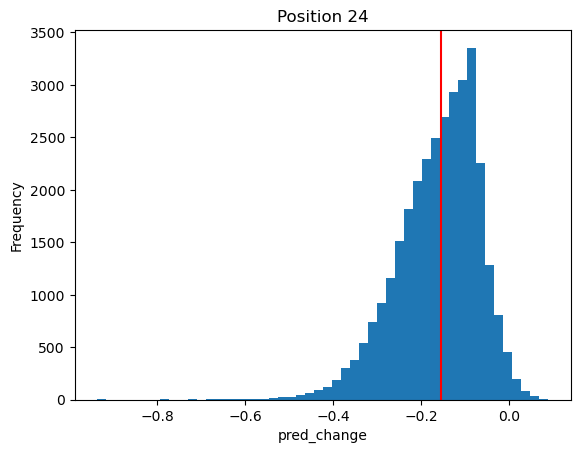

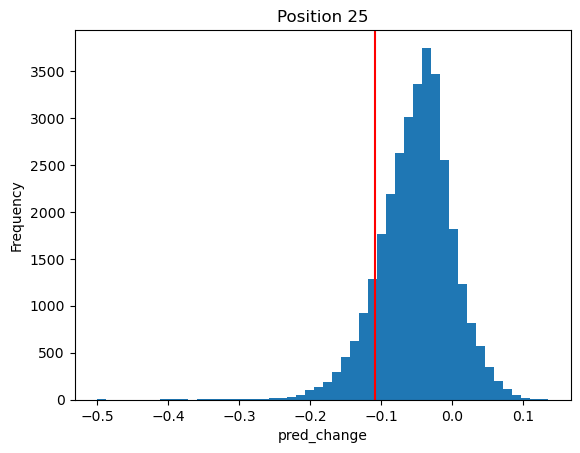

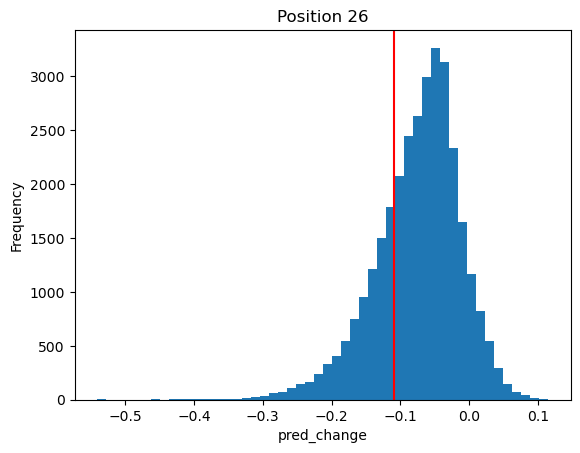

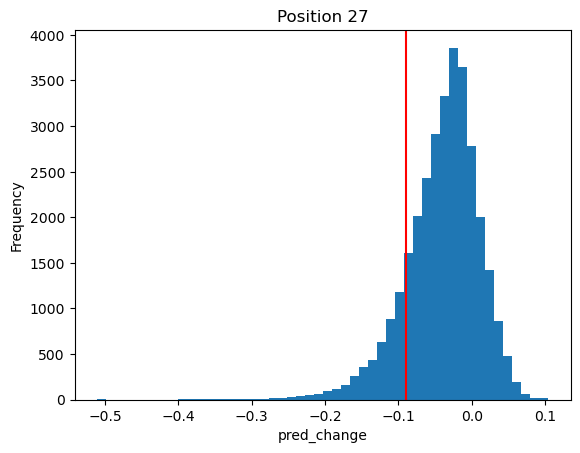

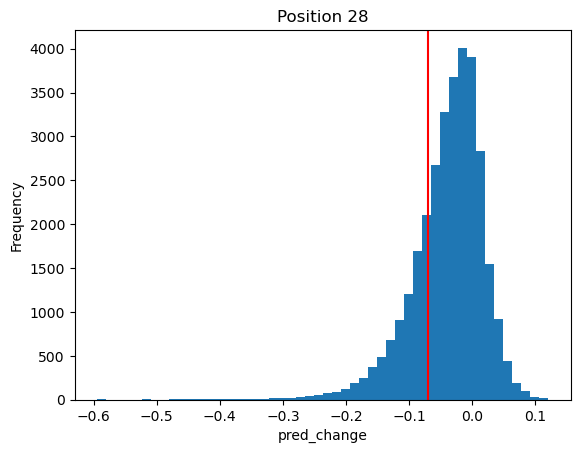

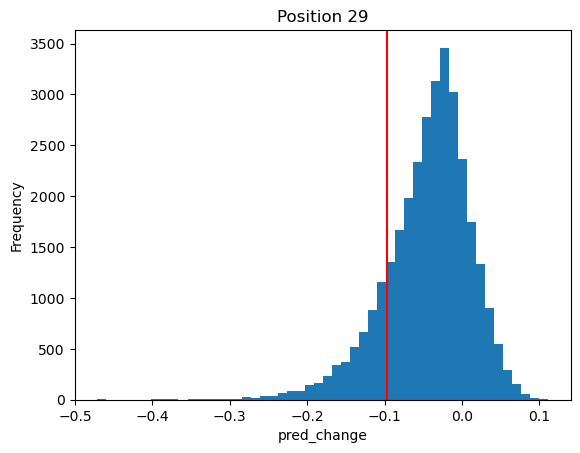

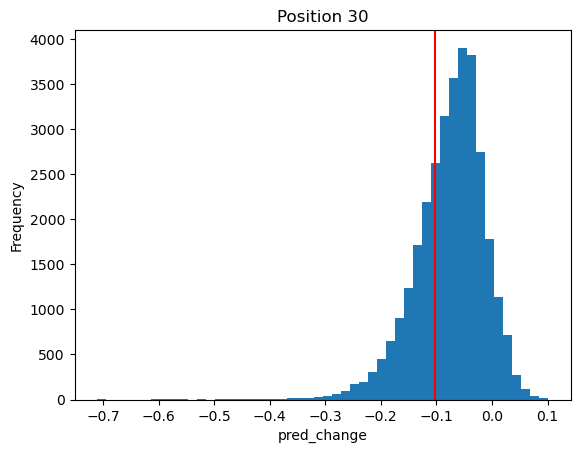

In [9]:
import matplotlib.pyplot as plt

positions = df[df['position'] != -1]['position'].unique()
for pos in positions:
    subset = df[df['position'] == pos]
    plt.figure()
    plt.hist(subset['pred_change'], bins=50)
    val = subset[subset['new_token'] == 4]['pred_change'].values[0]
    plt.axvline(x=val, color='red')
    plt.title(f'Position {pos}')
    plt.xlabel('pred_change')
    plt.ylabel('Frequency')
    plt.show()

0.029113667117636497
Mean: 5.312694952564142, Median: 5.317762
Diff: -0.025276552564141852
Diff median: -0.030343600000000137
Z-score of origPred: -0.6131257779138628
Z-score of val: -1.061423571815245


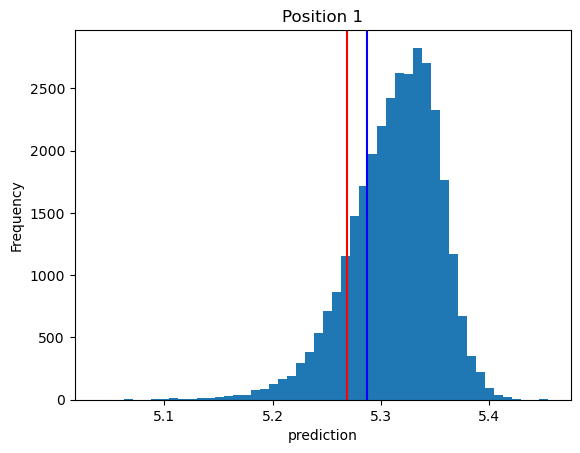

0.020030199339077435
Mean: 5.31202422208819, Median: 5.3152714
Diff: -0.024605822088189733
Diff median: -0.02785300000000035
Z-score of origPred: -0.7322996746152612
Z-score of val: -1.3222090350257665


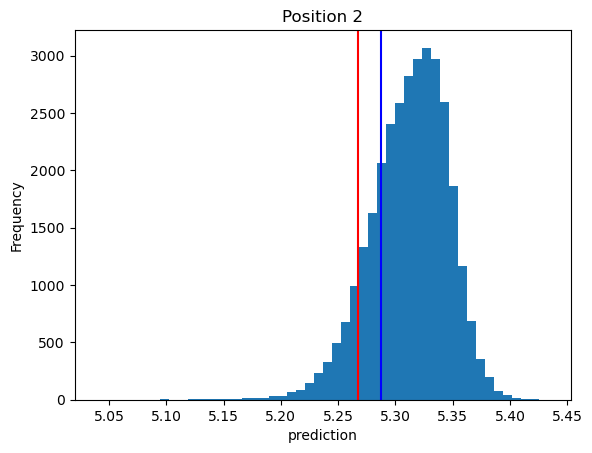

0.014698097822147248
Mean: 5.316152942851339, Median: 5.321336
Diff: -0.02873454285133903
Diff median: -0.03391759999999966
Z-score of origPred: -0.7849654989318617
Z-score of val: -0.9272641011782994


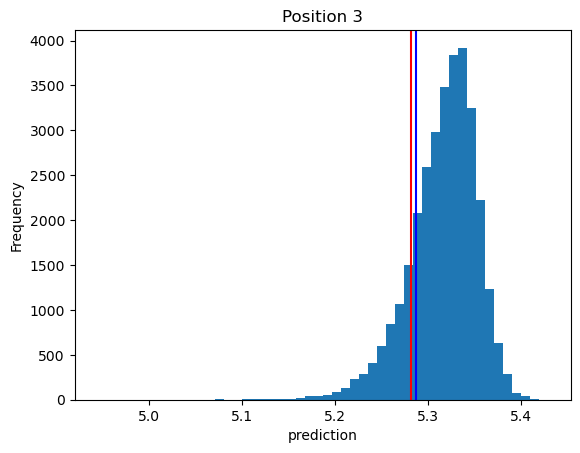

0.030656441407217763
Mean: 5.274063015928623, Median: 5.279207
Diff: 0.013355384071377152
Diff median: 0.008211399999999536
Z-score of origPred: 0.3107408483510202
Z-score of val: -1.258028356906148


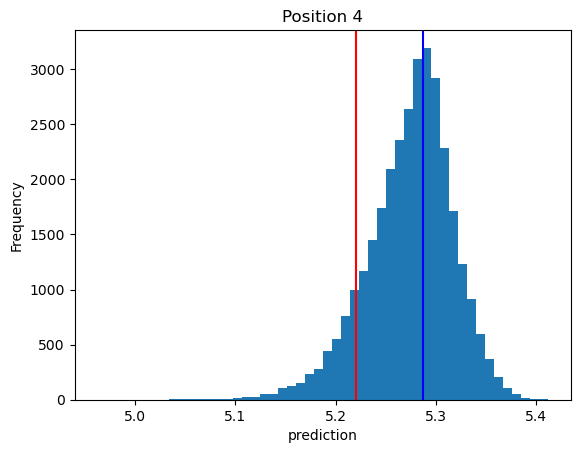

0.03463464401082498
Mean: 5.32127724781712, Median: 5.32658
Diff: -0.03385884781712001
Diff median: -0.03916159999999991
Z-score of origPred: -0.9338106414515059
Z-score of val: -1.1081407632706615


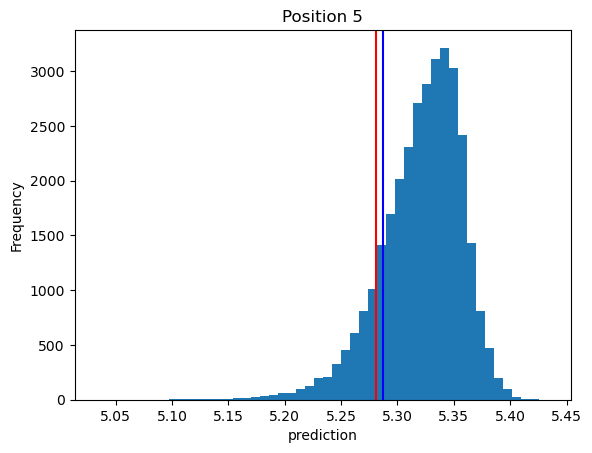

0.04364564782042027
Mean: 5.235158636435514, Median: 5.2408504
Diff: 0.052259763564485695
Diff median: 0.04656799999999972
Z-score of origPred: 1.2765154977415603
Z-score of val: -1.166141910774803


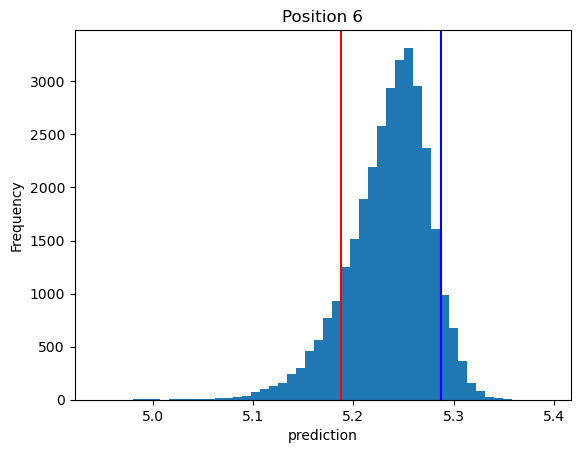

0.019397718680214452
Mean: 5.273797485168287, Median: 5.2782583
Diff: 0.013620914831713016
Diff median: 0.009160099999999893
Z-score of origPred: 0.3666109834847504
Z-score of val: -1.4000930365214168


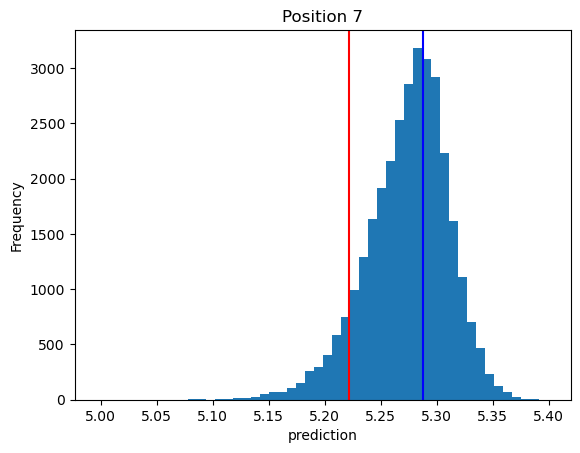

0.01926716893693785
Mean: 5.265726170308446, Median: 5.27318
Diff: 0.0216922296915536
Diff median: 0.014238399999999984
Z-score of origPred: 0.44728805726104837
Z-score of val: -0.7610573609595429


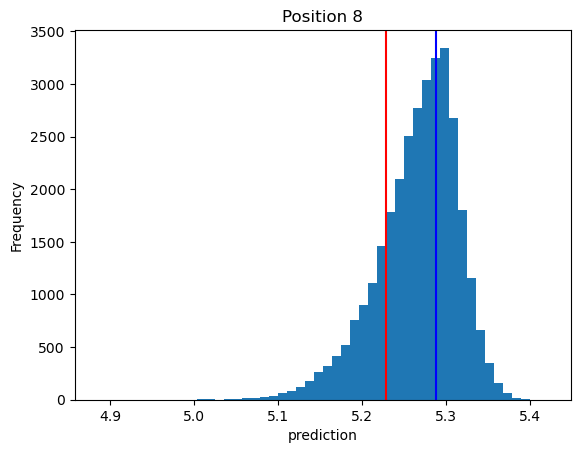

0.05788130252032635
Mean: 5.256103754954843, Median: 5.264328
Diff: 0.03131464504515691
Diff median: 0.023090400000000066
Z-score of origPred: 0.5369966400185182
Z-score of val: -0.8188242094765085


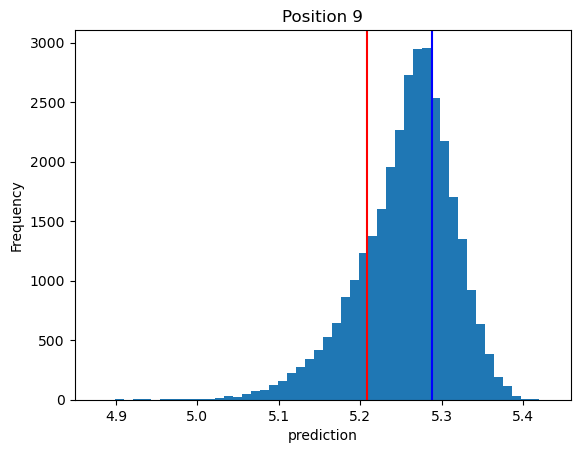

0.03842001629580414
Mean: 5.30278167938373, Median: 5.309053
Diff: -0.015363279383730166
Diff median: -0.021634599999999615
Z-score of origPred: -0.3372439487316445
Z-score of val: -0.927668054319487


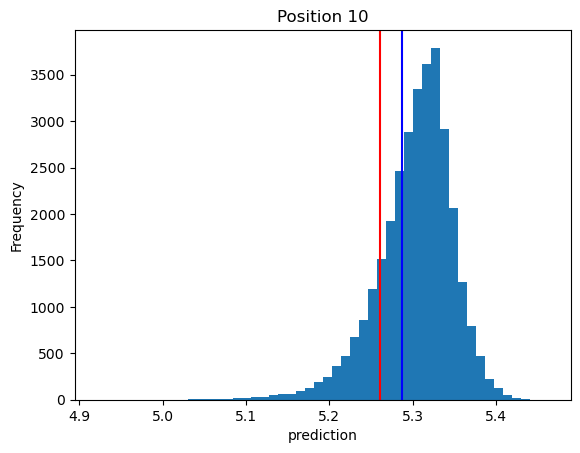

0.05229942817620656
Mean: 5.218550506965842, Median: 5.2301435
Diff: 0.06886789303415775
Diff median: 0.05727490000000035
Z-score of origPred: 1.0757682870862812
Z-score of val: -0.44412152311317854


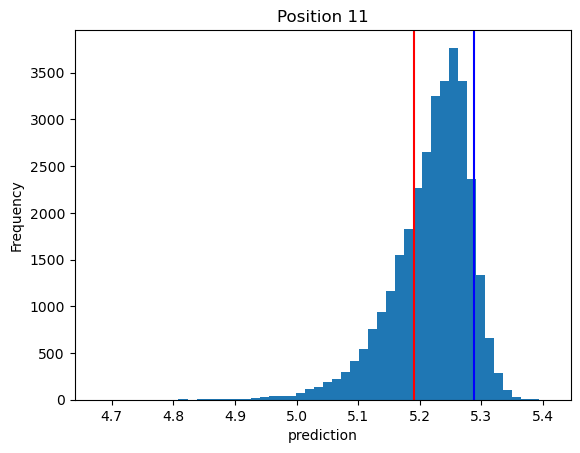

0.046136166401064785
Mean: 5.300552955089221, Median: 5.3039885
Diff: -0.01313455508922079
Diff median: -0.016570100000000032
Z-score of origPred: -0.37988038247415135
Z-score of val: -1.9752585003712382


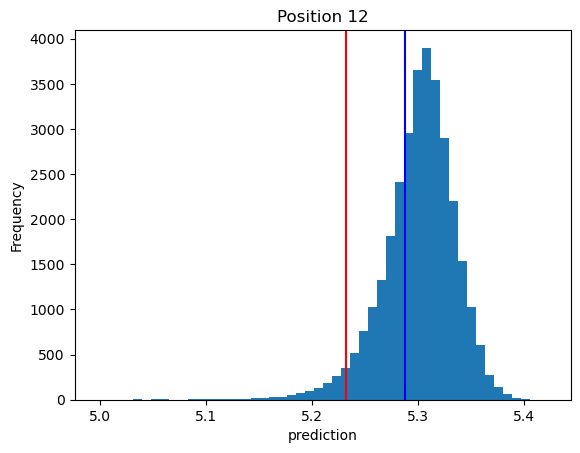

0.03330041706685915
Mean: 5.271690847823369, Median: 5.2799478
Diff: 0.015727552176630688
Diff median: 0.00747059999999955
Z-score of origPred: 0.31748930582791196
Z-score of val: -1.1226608244418752


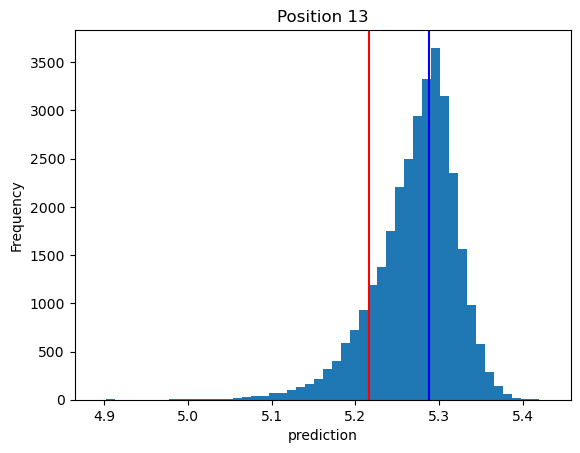

0.033895526412563076
Mean: 5.289541610778461, Median: 5.294648
Diff: -0.0021232107784614485
Diff median: -0.007229599999999614
Z-score of origPred: -0.049292605482793295
Z-score of val: -1.57903181830956


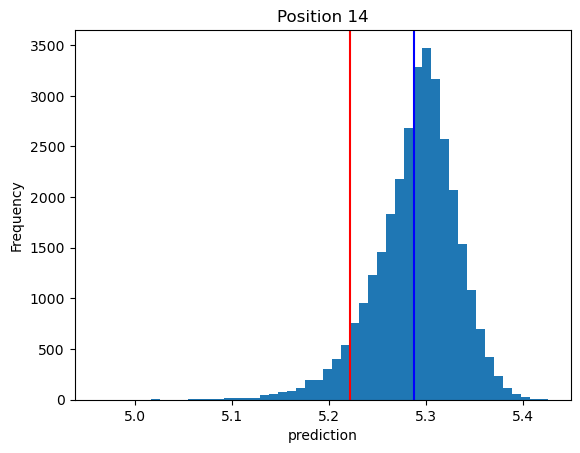

0.04483794884546768
Mean: 5.280062876018, Median: 5.2855015
Diff: 0.007355523981999568
Diff median: 0.0019169000000003322
Z-score of origPred: 0.143134409178862
Z-score of val: -1.220766365701579


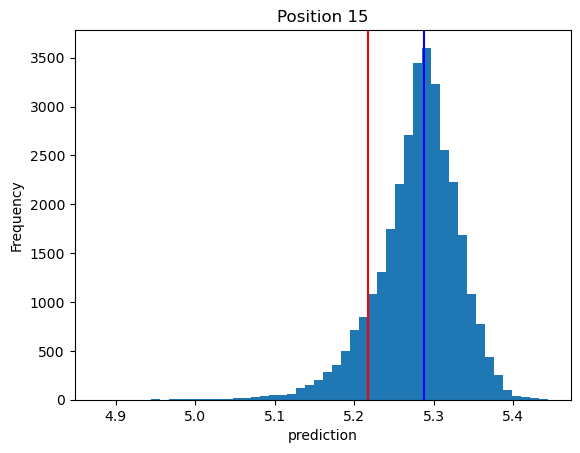

0.032298697306854265
Mean: 5.329275030763462, Median: 5.3347764
Diff: -0.04185663076346202
Diff median: -0.04735800000000001
Z-score of origPred: -0.9927771622118162
Z-score of val: -1.2342648599786041


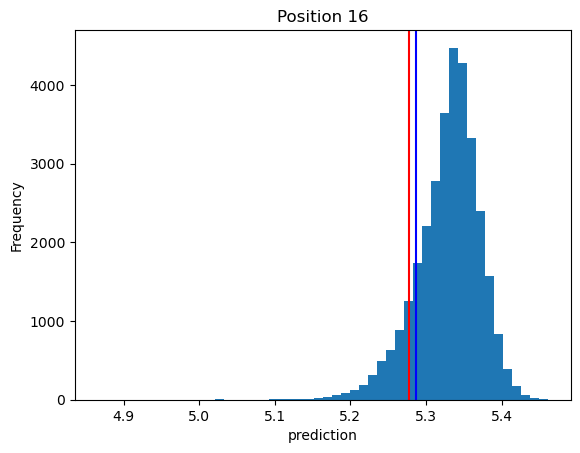

0.029133646128298923
Mean: 5.3065603002406325, Median: 5.313712
Diff: -0.01914190024063256
Diff median: -0.026293599999999806
Z-score of origPred: -0.3603868306348111
Z-score of val: -0.9628056829740594


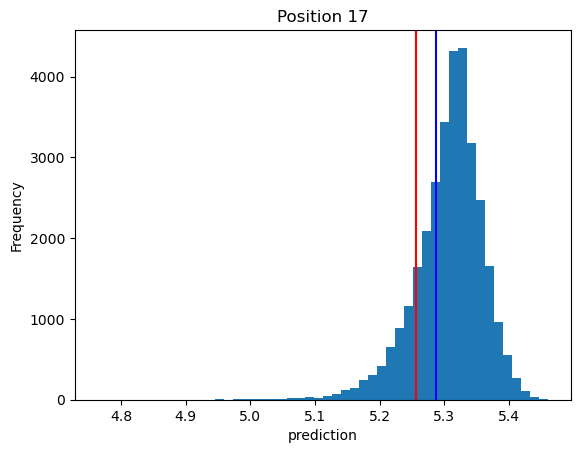

0.03832703580461125
Mean: 5.318404307703366, Median: 5.329852
Diff: -0.030985907703366067
Diff median: -0.04243359999999985
Z-score of origPred: -0.5710418386412421
Z-score of val: -0.9992747348070535


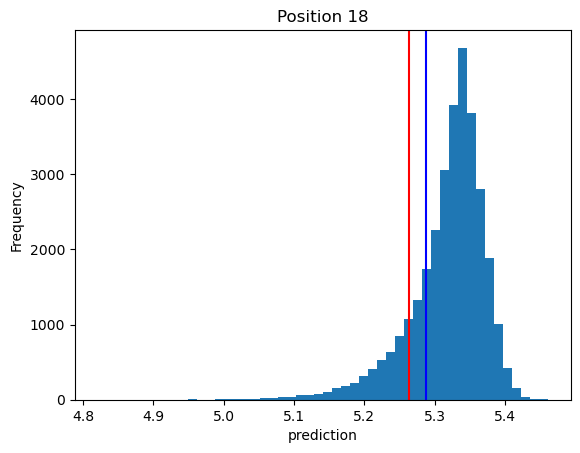

0.02710306676647436
Mean: 5.271246222638208, Median: 5.278989
Diff: 0.016172177361791995
Diff median: 0.00842939999999981
Z-score of origPred: 0.30851750489114727
Z-score of val: -1.2210692587385654


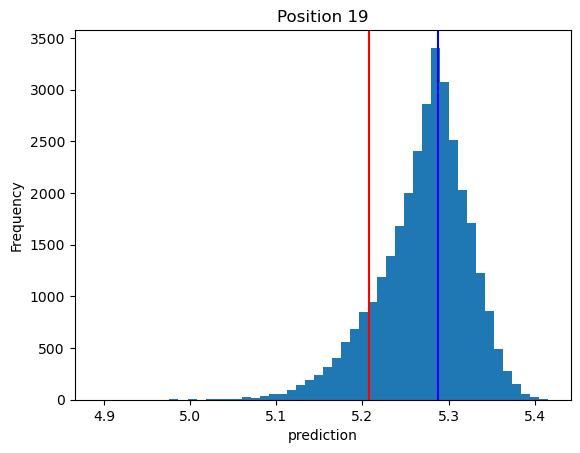

0.054318040473183234
Mean: 5.2977395728397765, Median: 5.303961
Diff: -0.010321172839776516
Diff median: -0.016542600000000185
Z-score of origPred: -0.20723639156792725
Z-score of val: -1.1776591089349937


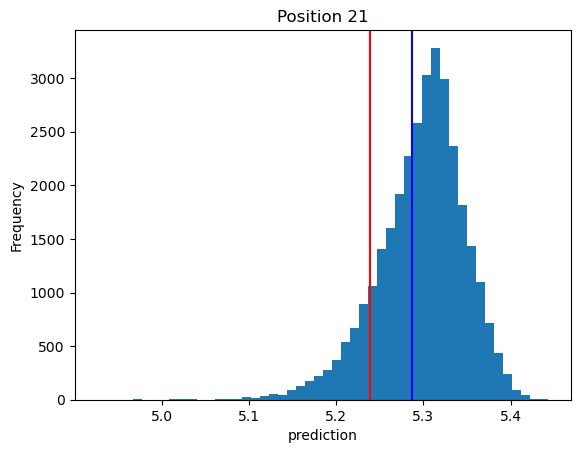

0.028749226300328924
Mean: 5.260597852611018, Median: 5.2755885
Diff: 0.026820547388981986
Diff median: 0.011829900000000393
Z-score of origPred: 0.3906058616062654
Z-score of val: -0.5241942024611383


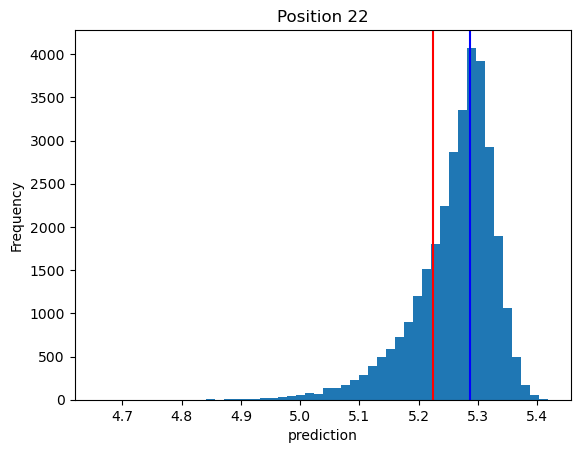

0.0015931873626320518
Mean: 5.384325071383481, Median: 5.3890924
Diff: -0.09690667138348097
Diff median: -0.10167400000000004
Z-score of origPred: -2.56925084674653
Z-score of val: -1.8609765072133393


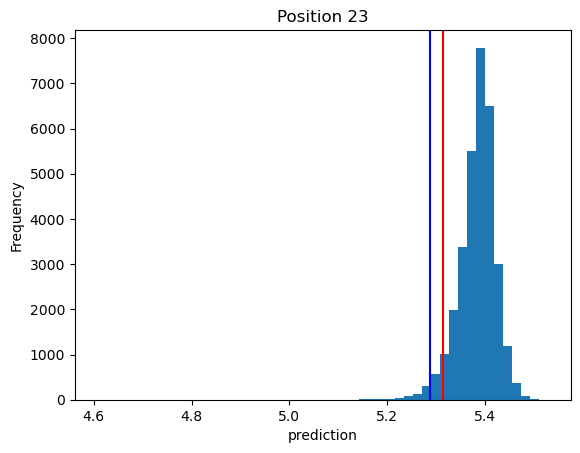

0.05240315544117436
Mean: 5.1258324262914465, Median: 5.139232
Diff: 0.16158597370855343
Diff median: 0.14818640000000016
Z-score of origPred: 1.7504578647375173
Z-score of val: 0.06947812536910465


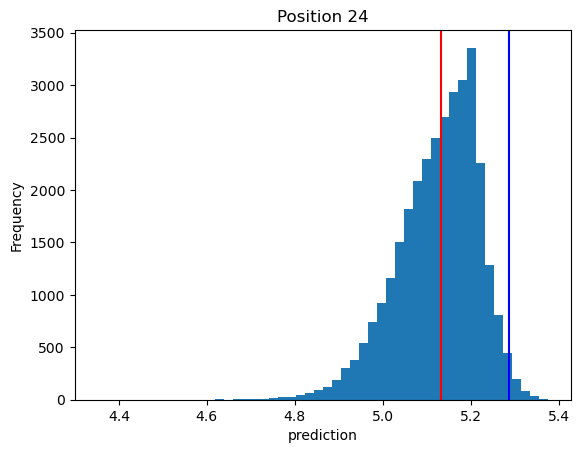

0.06973659628227236
Mean: 5.2367942662614455, Median: 5.240904
Diff: 0.050624133738554455
Diff median: 0.0465144000000004
Z-score of origPred: 0.9969248677024108
Z-score of val: -1.1460128808972931


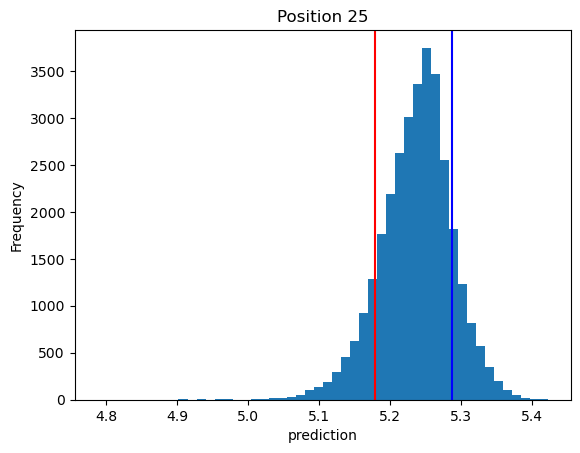

0.05021874005696981
Mean: 5.212680494512328, Median: 5.221054
Diff: 0.07473790548767223
Diff median: 0.06636440000000032
Z-score of origPred: 1.2033303130499104
Z-score of val: -0.5498780256791305


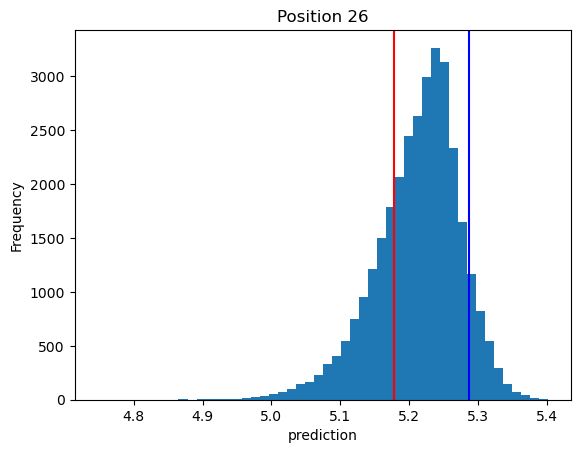

0.025585046552747657
Mean: 5.247047961492547, Median: 5.254244
Diff: 0.04037043850745281
Diff median: 0.03317440000000005
Z-score of origPred: 0.7974228796875388
Z-score of val: -0.9637800972423749


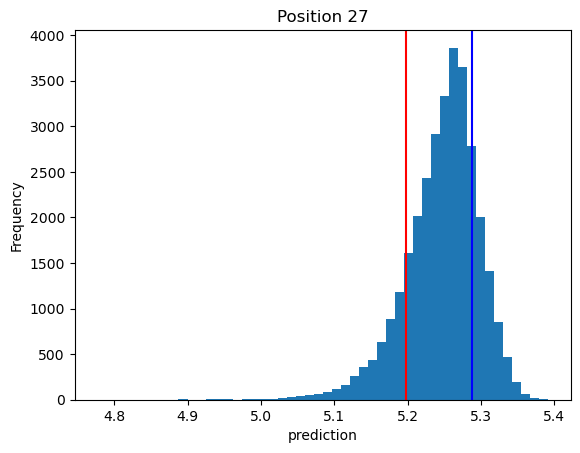

0.023717173819838493
Mean: 5.248045198631207, Median: 5.2570605
Diff: 0.039373201368793076
Diff median: 0.03035790000000027
Z-score of origPred: 0.695113183884209
Z-score of val: -0.5329338354426922


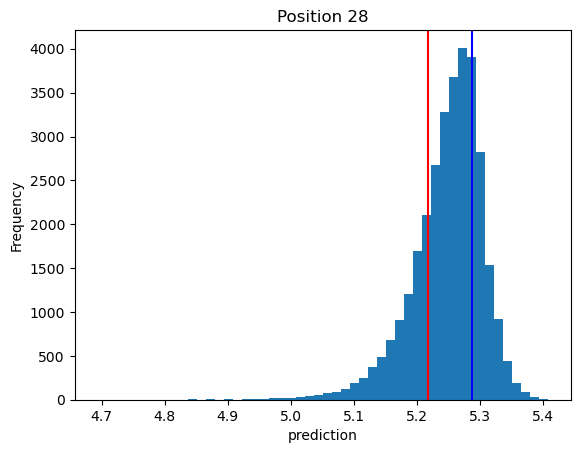

0.023121528956342594
Mean: 5.243218743938874, Median: 5.25134
Diff: 0.04419965606112619
Diff median: 0.036078400000000066
Z-score of origPred: 0.7951764279255965
Z-score of val: -0.9451059130453948


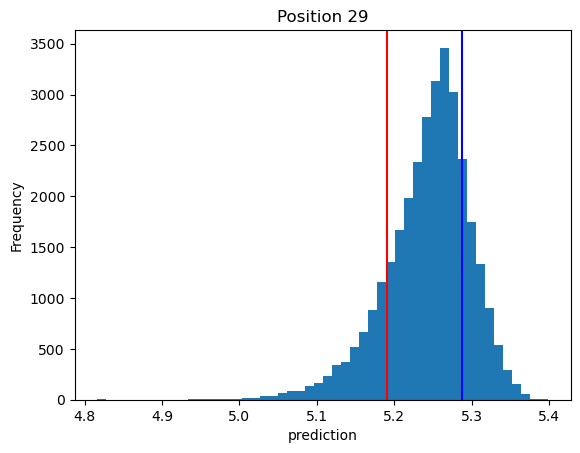

0.025474555823498415
Mean: 5.211761235785493, Median: 5.2199507
Diff: 0.07565716421450652
Diff median: 0.06746769999999991
Z-score of origPred: 1.213376093611096
Z-score of val: -0.43425987379116154


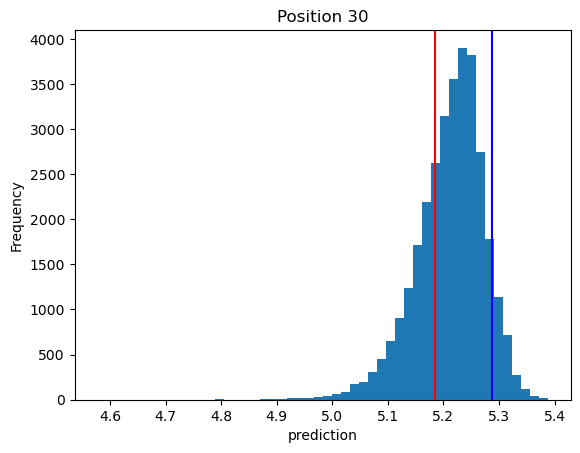

In [46]:
import matplotlib.pyplot as plt

positions = df[df['position'] != -1]['position'].unique()
origPred = df[df['position'] == -1]['prediction'].values[0]
diffs = []
diffsMedian = []
origZs = []
valZs = []
scoreList = []
for pos in positions:
    print(scores[pos])
    scoreList.append(scores[pos])
    subset = df[df['position'] == pos]
    val = subset[subset['new_token'] == 4]['prediction'].values[0]
    mean = subset['prediction'].mean()
    median = subset['prediction'].median()
    std = subset['prediction'].std()
    z_orig = (origPred - mean) / std
    z_val = (val - mean) / std
    print(f"Mean: {mean}, Median: {median}")
    print(f"Diff: {origPred- mean}")
    print(f"Diff median: {origPred - median}")
    print(f"Z-score of origPred: {z_orig}")
    print(f"Z-score of val: {z_val}")
    diffs.append(origPred - mean)
    diffsMedian.append(origPred - median)
    origZs.append(z_orig)
    valZs.append(z_val)
    subset = df[df['position'] == pos]
    plt.figure()
    plt.hist(subset['prediction'], bins=50)
    plt.axvline(x=origPred, color='blue')
    plt.axvline(x=val, color='red')
    plt.title(f'Position {pos}')
    plt.xlabel('prediction')
    plt.ylabel('Frequency')
    plt.show()

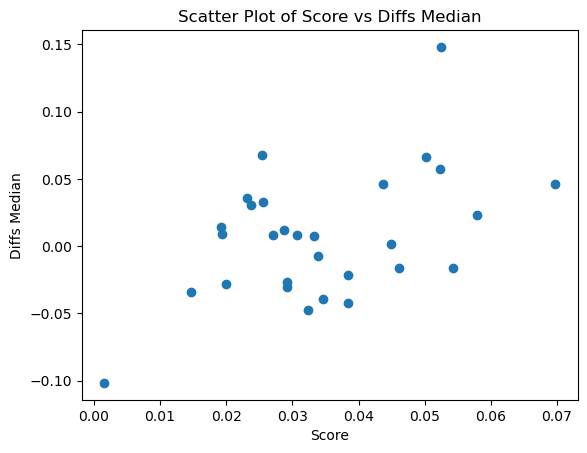

In [35]:
import matplotlib.pyplot as plt

plt.scatter(scoreList, diffsMedian)
plt.xlabel('Score')
plt.ylabel('Diffs Median')
plt.title('Scatter Plot of Score vs Diffs Median')
plt.show()

In [40]:
import pickle
import os
try:
    os.chdir('scripts')
    print(os.getcwd())
    from myShap import Explainer
    from myShap.ferret_extras import BaseExplainer, Explanation
    os.chdir('..')
    print(os.getcwd())
    importances = pickle.load(open('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/decay/output/importance/train_shap.pkl', 'rb')) 
except:
    os.chdir('../../scripts')
    print(os.getcwd())
    from myShap import Explainer
    from myShap.ferret_extras import BaseExplainer, Explanation
    os.chdir('..')
    print(os.getcwd())
    importances = pickle.load(open('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/decay/output/importance/train_shap.pkl', 'rb')) 

uniqueTokens = set()
for imp in importances:
    uniqueTokens.update(imp.tokens)

tokenIDs = []
for token in uniqueTokens:
    tokenIDs.append(tokenizer.convert_tokens_to_ids(token))
print(len(tokenIDs))
tokenIDs

/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/decay/scripts
/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/decay
11465


[0,
 20909,
 1053,
 7746,
 15386,
 5653,
 3550,
 13823,
 3634,
 4414,
 15989,
 12414,
 320,
 2776,
 24412,
 20352,
 1084,
 898,
 16807,
 9354,
 5981,
 1982,
 6182,
 5383,
 24623,
 18798,
 28743,
 2795,
 13773,
 12236,
 22456,
 8452,
 17218,
 27240,
 31578,
 2508,
 4905,
 13348,
 28475,
 1955,
 21889,
 1557,
 1973,
 2781,
 23805,
 12260,
 14022,
 17921,
 30554,
 949,
 1174,
 2757,
 26922,
 1309,
 3640,
 4022,
 3079,
 2457,
 14316,
 19270,
 1439,
 17719,
 13976,
 470,
 9674,
 5514,
 5530,
 26927,
 10403,
 1486,
 6972,
 3733,
 2036,
 537,
 2411,
 1924,
 2000,
 5289,
 12347,
 7455,
 7292,
 1044,
 2603,
 17211,
 13936,
 1874,
 1560,
 2876,
 8571,
 491,
 2837,
 161,
 24377,
 14976,
 7496,
 8323,
 10210,
 562,
 18854,
 24459,
 4877,
 3716,
 27315,
 21259,
 1380,
 874,
 25082,
 5697,
 29862,
 6670,
 19347,
 3283,
 12266,
 2705,
 7909,
 14105,
 5808,
 22471,
 16204,
 3751,
 6878,
 28543,
 501,
 20912,
 13648,
 4188,
 17654,
 14501,
 18,
 28681,
 10126,
 941,
 50,
 1263,
 7085,
 267,
 10373,
 13

0.029113667117636497
Mean: 5.3046810294199735, Median: 5.3081403
Diff: -0.017262629419973585
Diff median: -0.02072189999999985
Z-score of origPred: -0.4027413815873354
Z-score of val: -0.8339169799614718


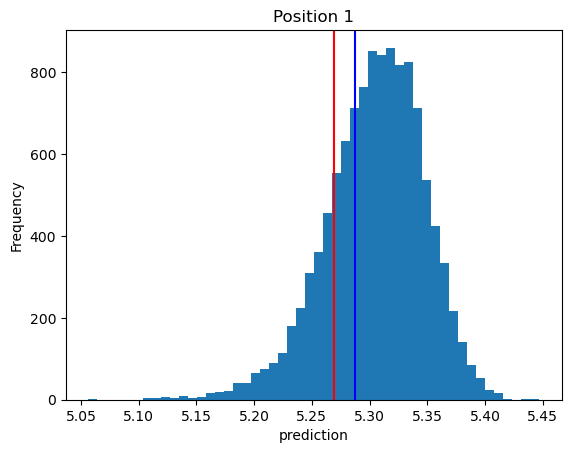

0.020030199339077435
Mean: 5.302730127518535, Median: 5.304345
Diff: -0.015311727518534823
Diff median: -0.01692659999999968
Z-score of origPred: -0.4279488738973014
Z-score of val: -0.9819389967491948


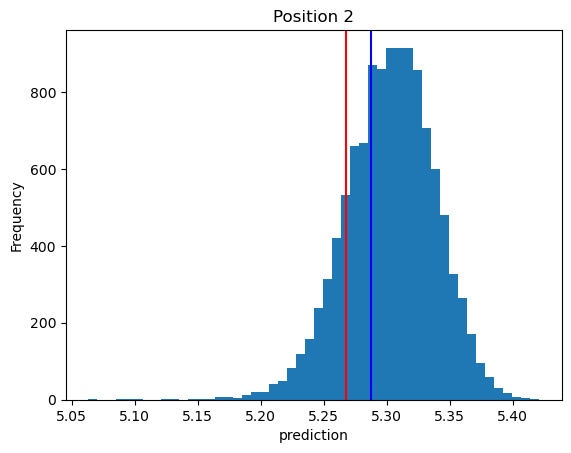

0.014698097822147248
Mean: 5.307314816842564, Median: 5.3106966
Diff: -0.019896416842564157
Diff median: -0.023278200000000027
Z-score of origPred: -0.5016275234495539
Z-score of val: -0.632956585879464


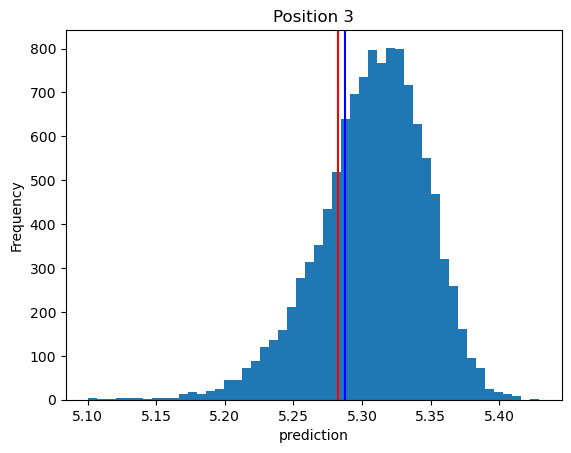

0.030656441407217763
Mean: 5.268500580183167, Median: 5.271655
Diff: 0.01891781981683316
Diff median: 0.015763399999999983
Z-score of origPred: 0.4125193221427329
Z-score of val: -1.0577276753010023


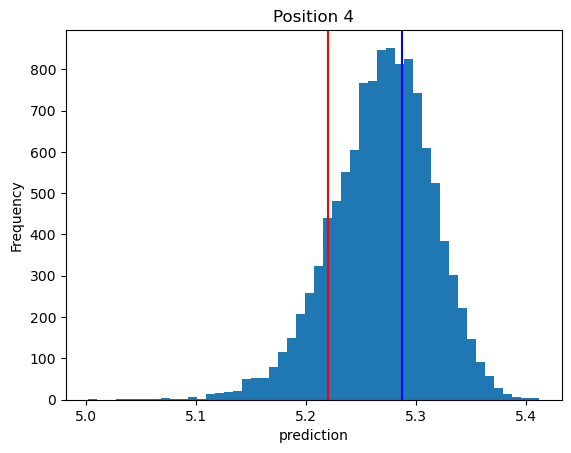

0.03463464401082498
Mean: 5.313973367597034, Median: 5.3186026
Diff: -0.026554967597034462
Diff median: -0.031184200000000217
Z-score of origPred: -0.6837019826679669
Z-score of val: -0.8464466825683618


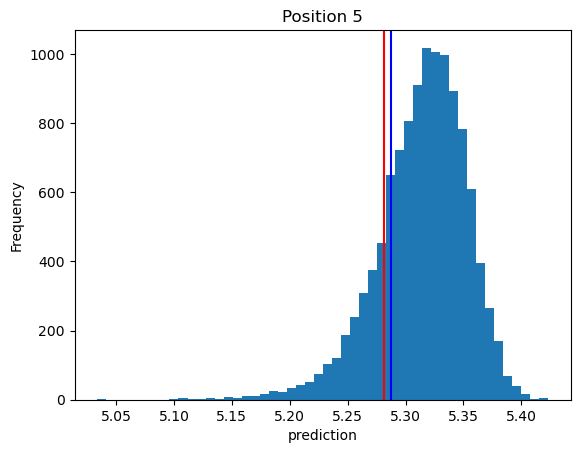

0.04364564782042027
Mean: 5.230320519930222, Median: 5.234551
Diff: 0.05709788006977767
Diff median: 0.05286740000000023
Z-score of origPred: 1.2967550018413305
Z-score of val: -0.9743742783554317


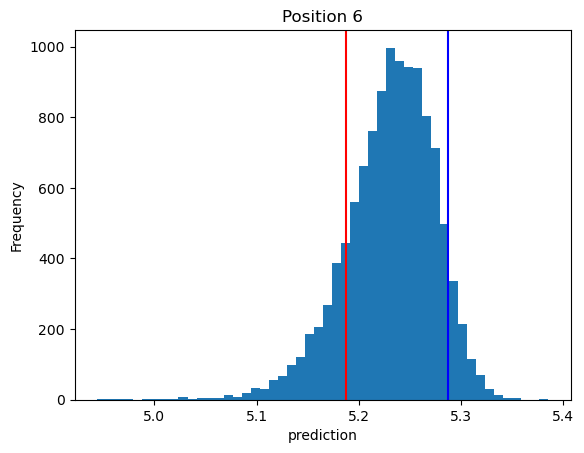

0.019397718680214452
Mean: 5.269807214304405, Median: 5.272495
Diff: 0.01761118569559539
Diff median: 0.014923399999999809
Z-score of origPred: 0.44203597940256045
Z-score of val: -1.2054951390532098


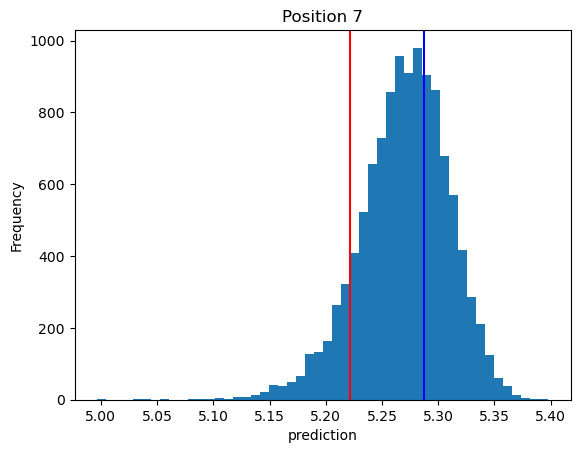

0.01926716893693785
Mean: 5.2601836488530305, Median: 5.2656317
Diff: 0.027234751146969494
Diff median: 0.021786699999999826
Z-score of origPred: 0.534160195066853
Z-score of val: -0.6151998665055715


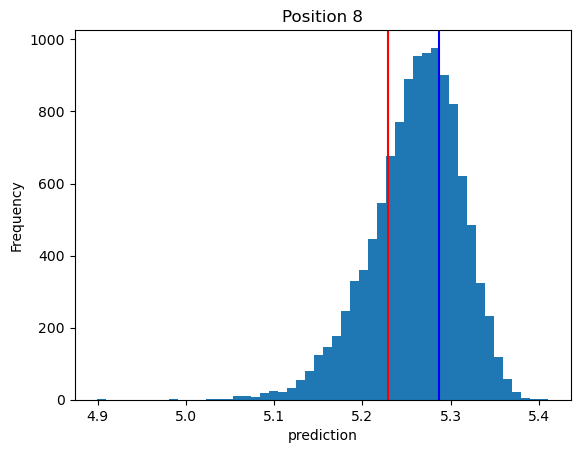

0.05788130252032635
Mean: 5.251923999825555, Median: 5.2589273
Diff: 0.03549440017444461
Diff median: 0.028491100000000102
Z-score of origPred: 0.5794393525265558
Z-score of val: -0.7112638231594078


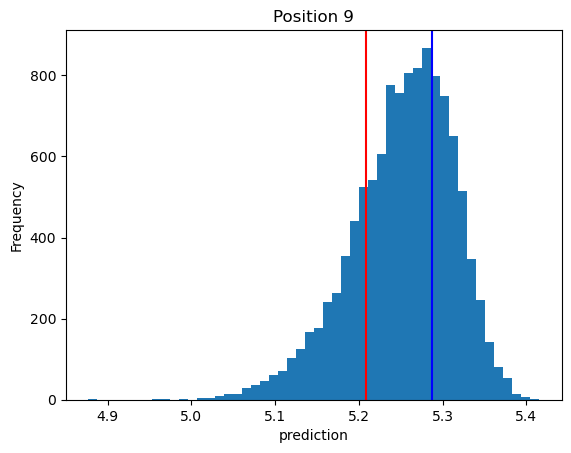

0.03842001629580414
Mean: 5.294613380148277, Median: 5.299115
Diff: -0.007194980148277352
Diff median: -0.011696599999999613
Z-score of origPred: -0.14178917046736877
Z-score of val: -0.6718397389840729


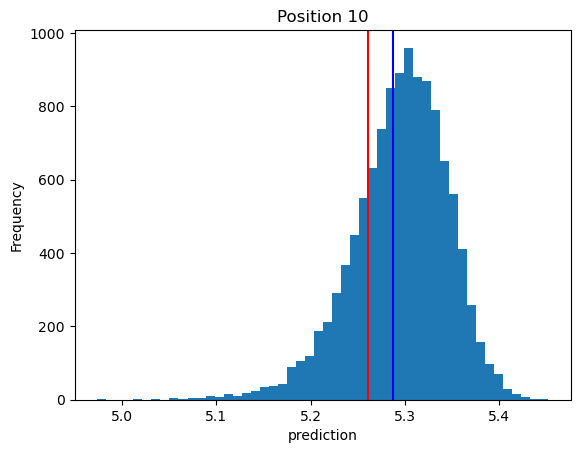

0.05229942817620656
Mean: 5.2164138276144785, Median: 5.22715
Diff: 0.07100457238552149
Diff median: 0.0602684
Z-score of origPred: 1.079908132011159
Z-score of val: -0.3999178815771157


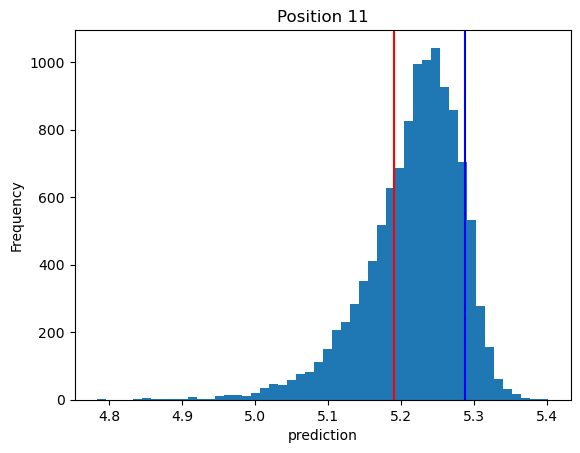

0.046136166401064785
Mean: 5.295817312647187, Median: 5.298918
Diff: -0.00839891264718684
Diff median: -0.01149959999999961
Z-score of origPred: -0.22659458748860148
Z-score of val: -1.7147853290181336


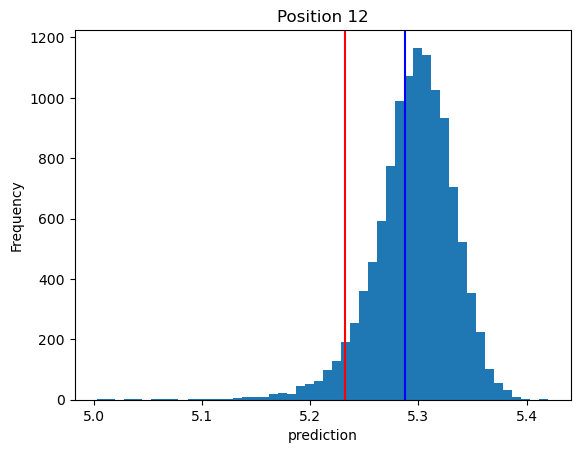

0.03330041706685915
Mean: 5.268309831783689, Median: 5.2755175
Diff: 0.019108568216310573
Diff median: 0.011900899999999659
Z-score of origPred: 0.36064171143205376
Z-score of val: -0.9858001626108139


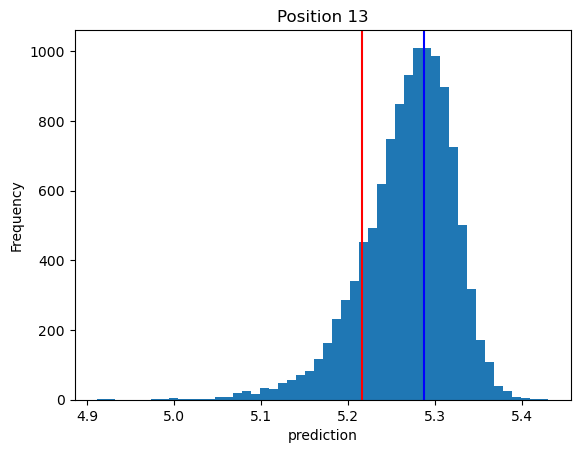

0.033895526412563076
Mean: 5.287537904256434, Median: 5.2921963
Diff: -0.0001195042564337001
Diff median: -0.0047778999999996685
Z-score of origPred: -0.0025468031746414942
Z-score of val: -1.4067848756040802


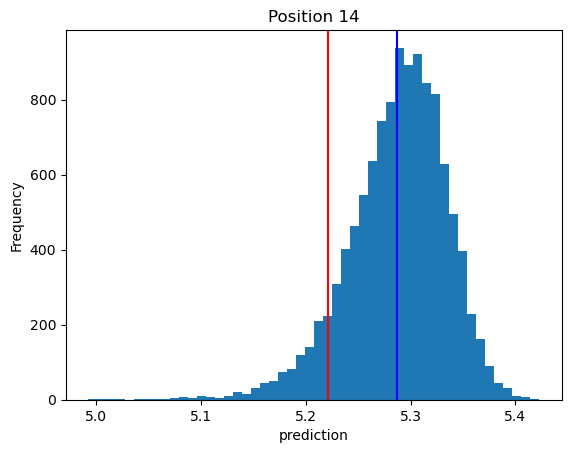

0.04483794884546768
Mean: 5.275626079310946, Median: 5.2819386
Diff: 0.011792320689053781
Diff median: 0.005479799999999813
Z-score of origPred: 0.20600889026375382
Z-score of val: -1.0184353810538764


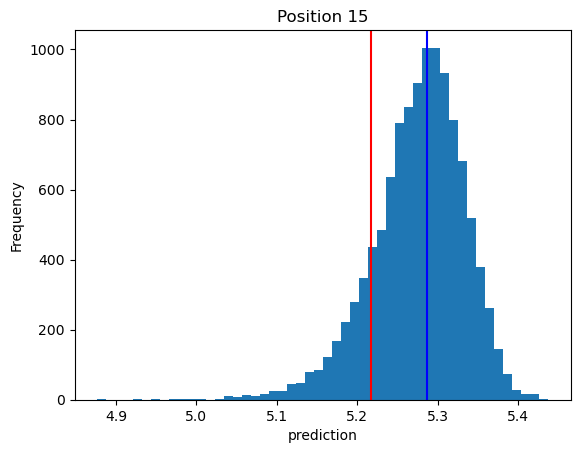

0.032298697306854265
Mean: 5.327111130388138, Median: 5.332117
Diff: -0.03969273038813803
Diff median: -0.044698600000000255
Z-score of origPred: -0.8607956154377191
Z-score of val: -1.0815943459185107


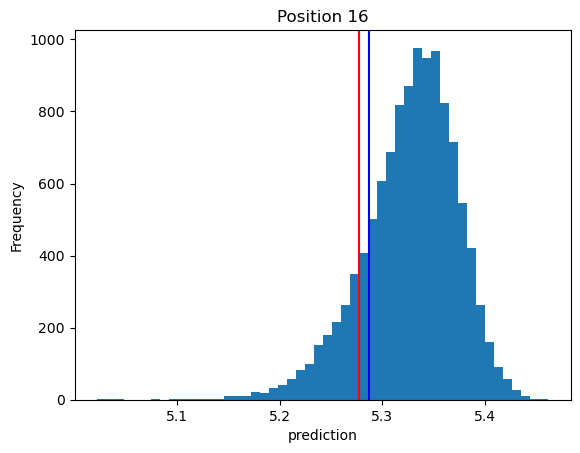

0.029133646128298923
Mean: 5.300630858822503, Median: 5.3072233
Diff: -0.013212458822502882
Diff median: -0.019804900000000458
Z-score of origPred: -0.23184908684944086
Z-score of val: -0.7933318563488835


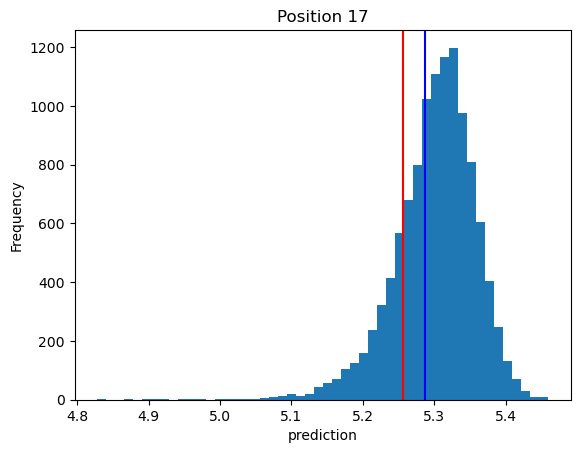

0.03832703580461125
Mean: 5.310981329402529, Median: 5.3216767
Diff: -0.023562929402529242
Diff median: -0.0342583000000003
Z-score of origPred: -0.39901008812838
Z-score of val: -0.7924975640458026


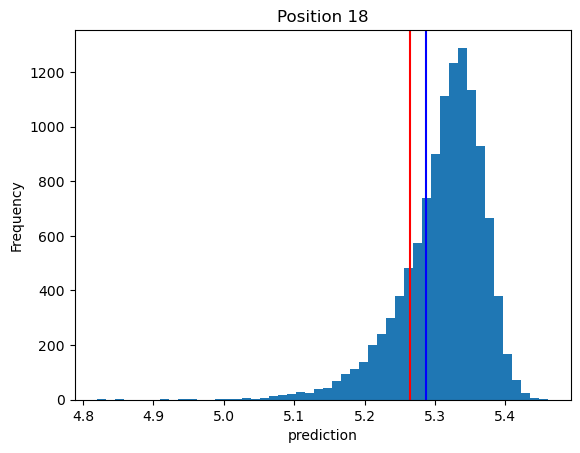

0.02710306676647436
Mean: 5.2682441869254255, Median: 5.2756314
Diff: 0.019174213074574453
Diff median: 0.011786999999999992
Z-score of origPred: 0.33489048093421964
Z-score of val: -1.065496472240022


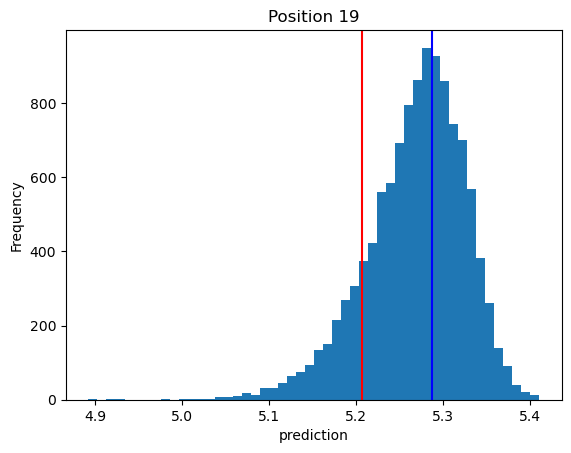

0.054318040473183234
Mean: 5.295000247928479, Median: 5.300374
Diff: -0.007581847928478602
Diff median: -0.012955599999999734
Z-score of origPred: -0.1387209045099003
Z-score of val: -1.0230029891589356


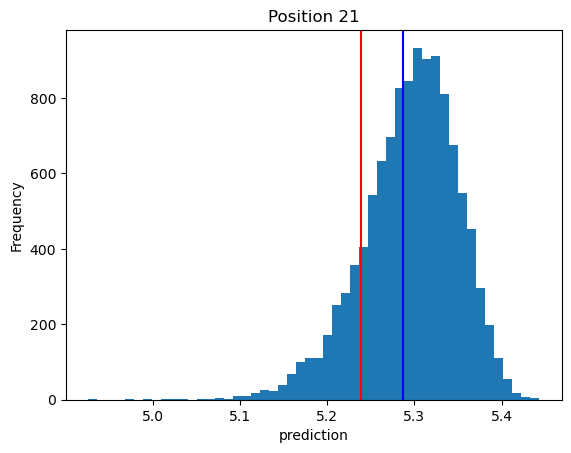

0.028749226300328924
Mean: 5.2612035265503705, Median: 5.271632
Diff: 0.026214873449629472
Diff median: 0.015786399999999645
Z-score of origPred: 0.3919299825961042
Z-score of val: -0.5471785577559402


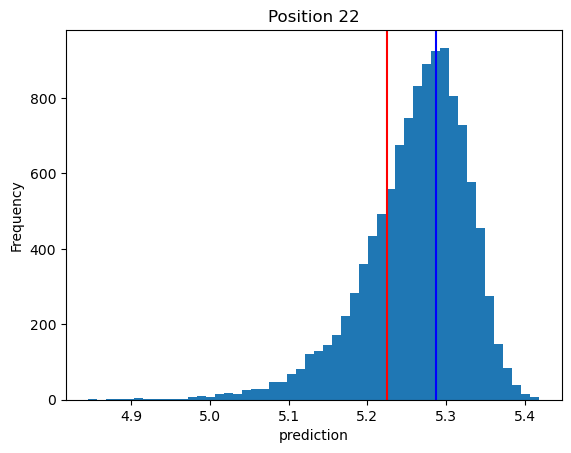

0.0015931873626320518
Mean: 5.377605206777148, Median: 5.38097
Diff: -0.0901868067771483
Diff median: -0.09355159999999962
Z-score of origPred: -2.1925833718148438
Z-score of val: -1.543109354074962


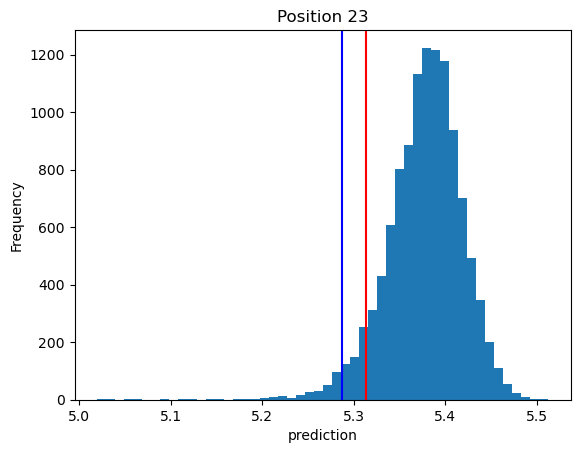

0.05240315544117436
Mean: 5.1267133547579595, Median: 5.1391025
Diff: 0.16070504524204043
Diff median: 0.14831590000000006
Z-score of origPred: 1.657450377955003
Z-score of val: 0.05706158716859341


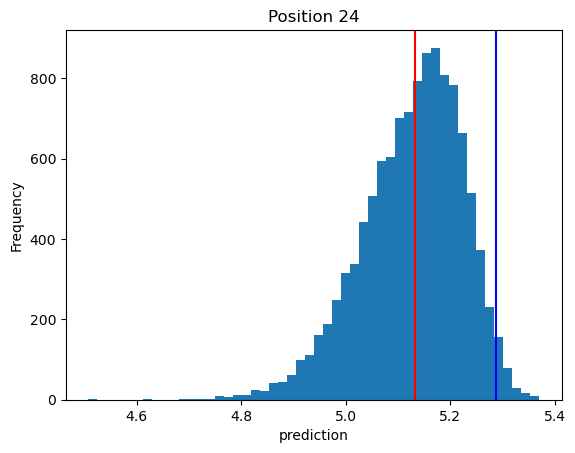

0.06973659628227236
Mean: 5.228845484047099, Median: 5.2306805
Diff: 0.05857291595290093
Diff median: 0.0567378999999999
Z-score of origPred: 1.0605189753498456
Z-score of val: -0.9097536754328539


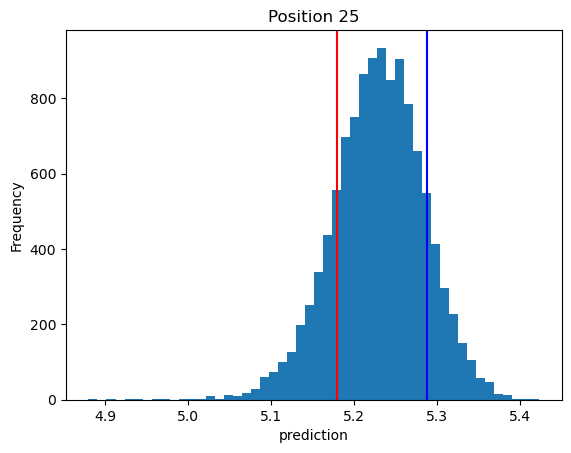

0.05021874005696981
Mean: 5.20778729047536, Median: 5.2152433
Diff: 0.07963110952464003
Diff median: 0.07217509999999994
Z-score of origPred: 1.131799850581697
Z-score of val: -0.4158633577482922


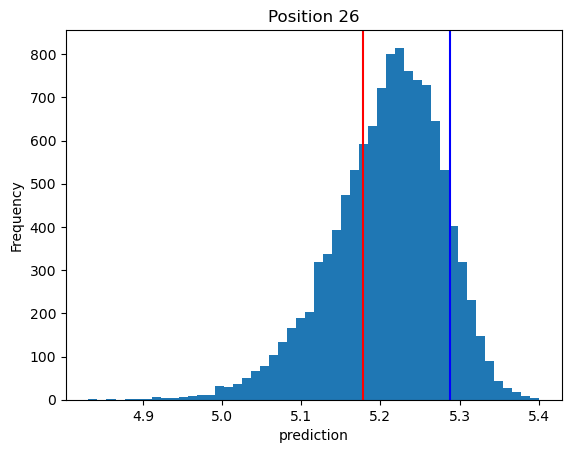

0.025585046552747657
Mean: 5.2411981822677705, Median: 5.2480264
Diff: 0.04622021773222951
Diff median: 0.039392000000000316
Z-score of origPred: 0.8131084805811533
Z-score of val: -0.755449905777449


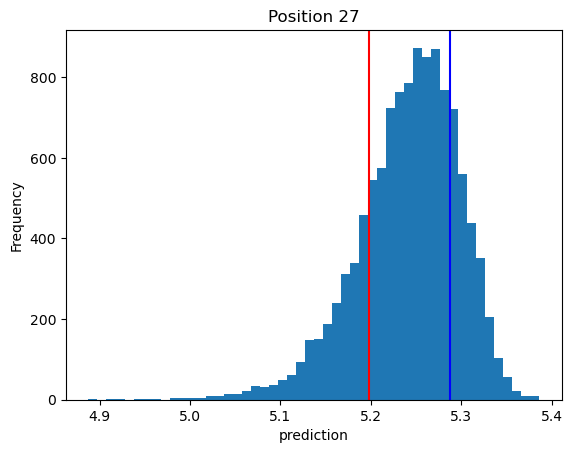

0.023717173819838493
Mean: 5.238996787265592, Median: 5.24774
Diff: 0.04842161273440837
Diff median: 0.03967839999999967
Z-score of origPred: 0.7654830683194086
Z-score of val: -0.33417214293231856


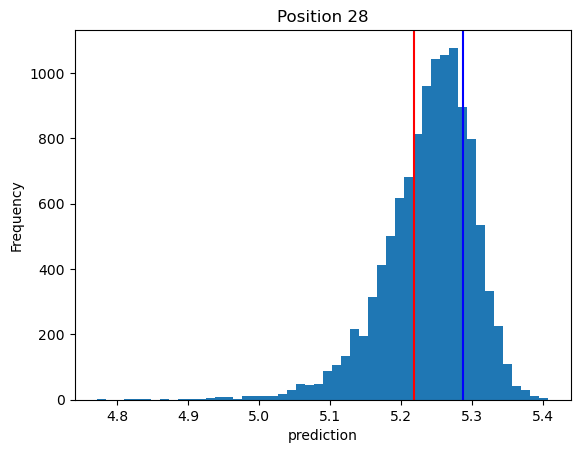

0.023121528956342594
Mean: 5.238613438761448, Median: 5.2461867
Diff: 0.04880496123855238
Diff median: 0.04123169999999998
Z-score of origPred: 0.7929125744255869
Z-score of val: -0.7786672282560191


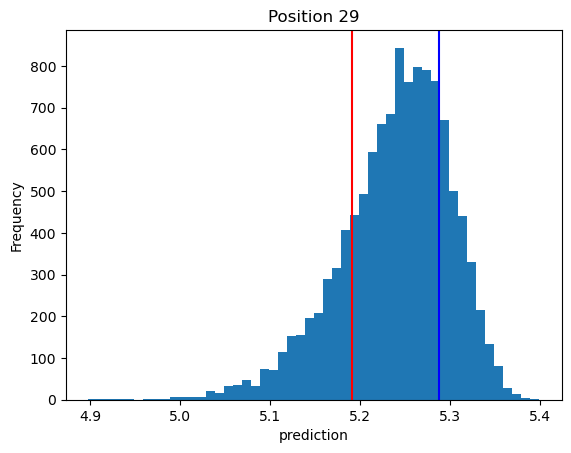

0.025474555823498415
Mean: 5.205596214958569, Median: 5.2118726
Diff: 0.0818221850414309
Diff median: 0.07554579999999955
Z-score of origPred: 1.165606475388578
Z-score of val: -0.2979071404422112


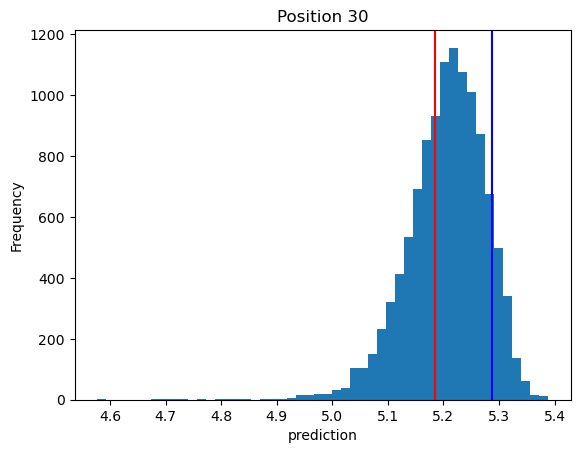

In [47]:
import matplotlib.pyplot as plt

positions = df[df['position'] != -1]['position'].unique()
origPred = df[df['position'] == -1]['prediction'].values[0]
tmp = df[df['new_token'].isin(tokenIDs+[4])]
diffs_short = []
diffsMedian_short = []
origZs_short = []
valZs_short = []
scoreList_short = []
for pos in positions:
    print(scores[pos])
    scoreList.append(scores[pos])
    subset = tmp[tmp['position'] == pos]
    val = subset[subset['new_token'] == 4]['prediction'].values[0]
    mean = subset['prediction'].mean()
    median = subset['prediction'].median()
    std = subset['prediction'].std()
    z_orig = (origPred - mean) / std
    z_val = (val - mean) / std
    print(f"Mean: {mean}, Median: {median}")
    print(f"Diff: {origPred- mean}")
    print(f"Diff median: {origPred - median}")
    print(f"Z-score of origPred: {z_orig}")
    print(f"Z-score of val: {z_val}")
    diffs_short.append(origPred - mean)
    diffsMedian_short.append(origPred - median)
    origZs_short.append(z_orig)
    valZs_short.append(z_val)
    subset = tmp[tmp['position'] == pos]
    plt.figure()
    plt.hist(subset['prediction'], bins=50)
    plt.axvline(x=origPred, color='blue')
    plt.axvline(x=val, color='red')
    plt.title(f'Position {pos}')
    plt.xlabel('prediction')
    plt.ylabel('Frequency')
    plt.show()

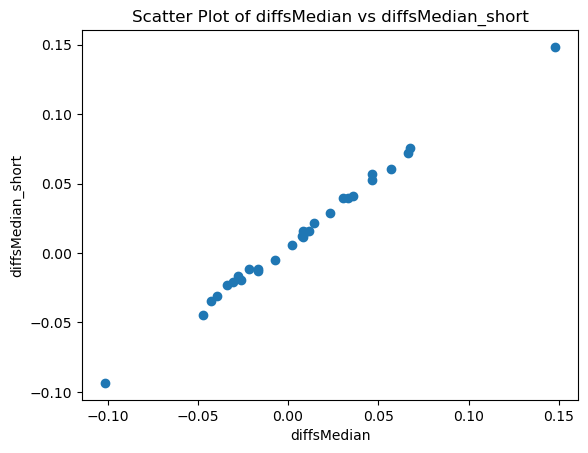

In [48]:
import matplotlib.pyplot as plt

plt.scatter(diffsMedian, diffsMedian_short)
plt.xlabel('diffsMedian')
plt.ylabel('diffsMedian_short')
plt.title('Scatter Plot of diffsMedian vs diffsMedian_short')
plt.show()

Correlations between each run's diffsMedian_sub and original diffsMedian: [0.9909214287985757, 0.9912121165659138, 0.9907970846301327, 0.9868001726137475, 0.990248328287991, 0.9878912976355019, 0.9795141234889945, 0.9922798148226358, 0.9896366519159753, 0.9888719275209891]
Mean correlation: 0.9888172946280458
Std of correlations: 0.0034679763640977704


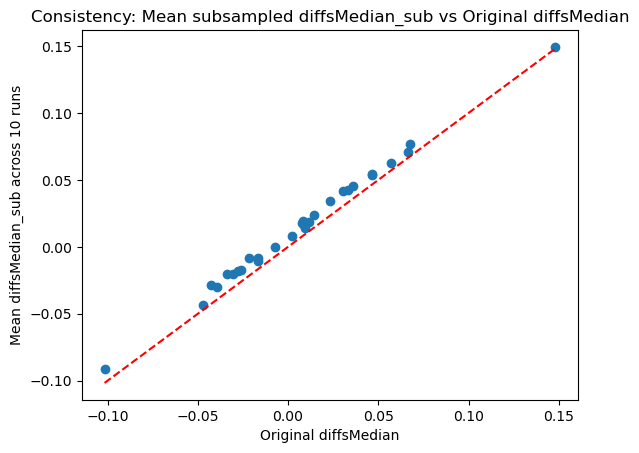

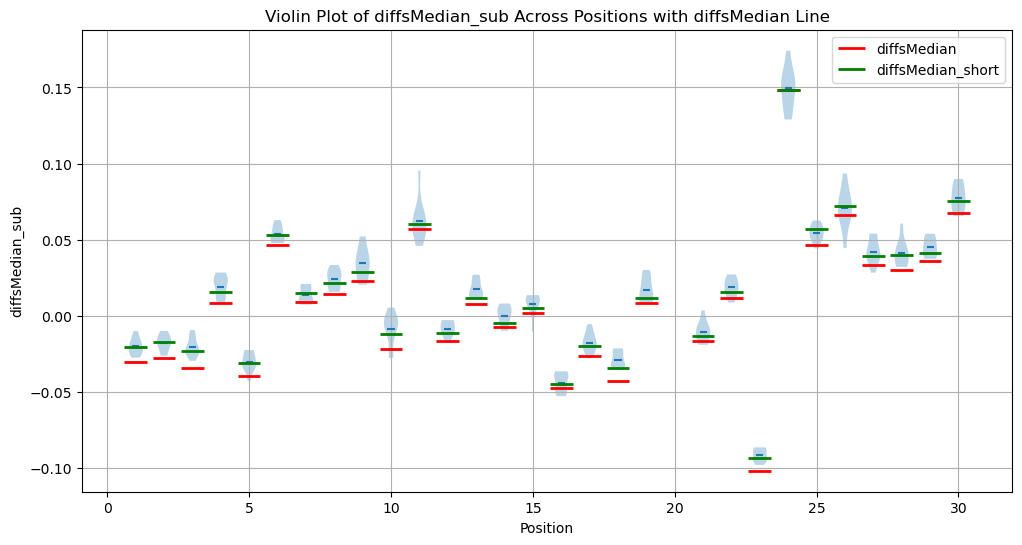

In [62]:
import random
import numpy as np

import matplotlib.pyplot as plt

positions = df[df['position'] != -1]['position'].unique()
origPred = df[df['position'] == -1]['prediction'].values[0]

all_diffsMedian_sub = []

for run in range(10):
    sampled_tokenIDs = random.sample(tokenIDs, 50)
    tmp = df[df['new_token'].isin(sampled_tokenIDs + [4])]
    diffs_sub = []
    diffsMedian_sub = []
    origZs_sub = []
    valZs_sub = []
    scoreList_sub = []
    for pos in positions:
        scoreList_sub.append(scores[pos])
        subset = tmp[tmp['position'] == pos]
        val = subset[subset['new_token'] == 4]['prediction'].values[0]
        mean = subset['prediction'].mean()
        median = subset['prediction'].median()
        std = subset['prediction'].std()
        z_orig = (origPred - mean) / std
        z_val = (val - mean) / std
        diffs_sub.append(origPred - mean)
        diffsMedian_sub.append(origPred - median)
        origZs_sub.append(z_orig)
        valZs_sub.append(z_val)
        # Removed plotting inside loop to avoid 290 figures; can add back if needed
    all_diffsMedian_sub.append(diffsMedian_sub)

# Analyze consistency
correlations = []
for d in all_diffsMedian_sub:
    corr = np.corrcoef(diffsMedian, d)[0, 1]
    correlations.append(corr)

print("Correlations between each run's diffsMedian_sub and original diffsMedian:", correlations)
print("Mean correlation:", np.mean(correlations))
print("Std of correlations:", np.std(correlations))

# Plot the average diffsMedian_sub vs original diffsMedian
mean_diffsMedian_sub = np.mean(all_diffsMedian_sub, axis=0)
plt.figure()
plt.scatter(diffsMedian, mean_diffsMedian_sub)
plt.xlabel('Original diffsMedian')
plt.ylabel('Mean diffsMedian_sub across 10 runs')
plt.title('Consistency: Mean subsampled diffsMedian_sub vs Original diffsMedian')
plt.plot([min(diffsMedian), max(diffsMedian)], [min(diffsMedian), max(diffsMedian)], 'r--')  # diagonal line
plt.show()

# Create violin plot for diffsMedian_sub across positions
import matplotlib.pyplot as plt

# Prepare data for violin plot: list of lists, one per position
violin_data = [ [all_diffsMedian_sub[run][i] for run in range(10)] for i in range(len(positions)) ]

# Create the violin plot
plt.figure(figsize=(12, 6))
plt.violinplot(violin_data, positions=positions, showmeans=True, showmedians=False, showextrema=False)

# Add red horizontal lines for diffsMedian at each position
for i, pos in enumerate(positions):
    plt.hlines(diffsMedian[i], pos - 0.4, pos + 0.4, color='red', linewidth=2, label='diffsMedian' if i == 0 else "")# Add red horizontal lines for diffsMedian at each position
    plt.hlines(diffsMedian_short[i], pos - 0.4, pos + 0.4, color='green', linewidth=2, label='diffsMedian_short' if i == 0 else "")

# Labels and title
plt.xlabel('Position')
plt.ylabel('diffsMedian_sub')
plt.title('Violin Plot of diffsMedian_sub Across Positions with diffsMedian Line')
plt.legend()
plt.grid(True)
plt.show()

Correlations between each run's diffsMedian_sub and original diffsMedian: [0.9914215807600195, 0.9937594645164963, 0.995052318739729, 0.9930668996324005, 0.9962761446292774, 0.9969021024350402, 0.9941595204678774, 0.996126330208187, 0.9921707754762124, 0.9960298925315835]
Mean correlation: 0.9944965029396823
Std of correlations: 0.0017842446113067734


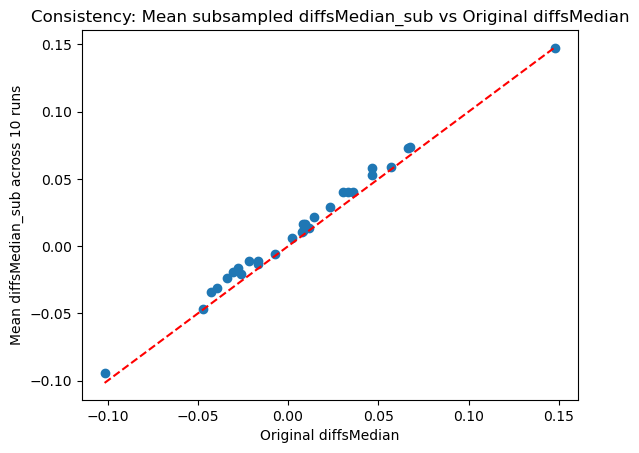

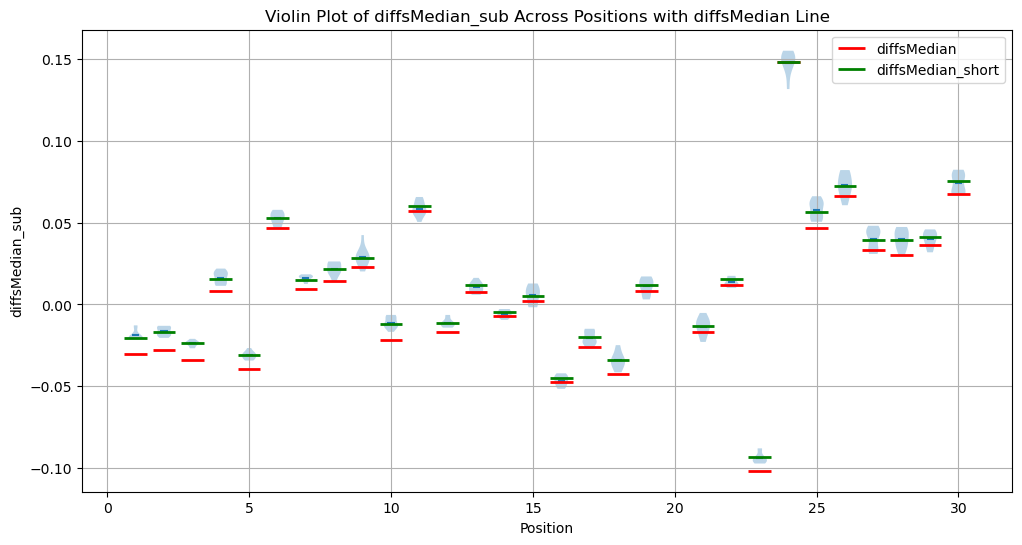

In [65]:
import random
import numpy as np

import matplotlib.pyplot as plt

positions = df[df['position'] != -1]['position'].unique()
origPred = df[df['position'] == -1]['prediction'].values[0]

all_diffsMedian_sub = []

for run in range(10):
    sampled_tokenIDs = random.sample(tokenIDs, 200)
    tmp = df[df['new_token'].isin(sampled_tokenIDs + [4])]
    diffs_sub = []
    diffsMedian_sub = []
    origZs_sub = []
    valZs_sub = []
    scoreList_sub = []
    for pos in positions:
        scoreList_sub.append(scores[pos])
        subset = tmp[tmp['position'] == pos]
        val = subset[subset['new_token'] == 4]['prediction'].values[0]
        mean = subset['prediction'].mean()
        median = subset['prediction'].median()
        std = subset['prediction'].std()
        z_orig = (origPred - mean) / std
        z_val = (val - mean) / std
        diffs_sub.append(origPred - mean)
        diffsMedian_sub.append(origPred - median)
        origZs_sub.append(z_orig)
        valZs_sub.append(z_val)
        # Removed plotting inside loop to avoid 290 figures; can add back if needed
    all_diffsMedian_sub.append(diffsMedian_sub)

# Analyze consistency
correlations = []
for d in all_diffsMedian_sub:
    corr = np.corrcoef(diffsMedian, d)[0, 1]
    correlations.append(corr)

print("Correlations between each run's diffsMedian_sub and original diffsMedian:", correlations)
print("Mean correlation:", np.mean(correlations))
print("Std of correlations:", np.std(correlations))

# Plot the average diffsMedian_sub vs original diffsMedian
mean_diffsMedian_sub = np.mean(all_diffsMedian_sub, axis=0)
plt.figure()
plt.scatter(diffsMedian, mean_diffsMedian_sub)
plt.xlabel('Original diffsMedian')
plt.ylabel('Mean diffsMedian_sub across 10 runs')
plt.title('Consistency: Mean subsampled diffsMedian_sub vs Original diffsMedian')
plt.plot([min(diffsMedian), max(diffsMedian)], [min(diffsMedian), max(diffsMedian)], 'r--')  # diagonal line
plt.show()

# Create violin plot for diffsMedian_sub across positions
import matplotlib.pyplot as plt

# Prepare data for violin plot: list of lists, one per position
violin_data = [ [all_diffsMedian_sub[run][i] for run in range(10)] for i in range(len(positions)) ]

# Create the violin plot
plt.figure(figsize=(12, 6))
plt.violinplot(violin_data, positions=positions, showmeans=True, showmedians=False, showextrema=False)

# Add red horizontal lines for diffsMedian at each position
for i, pos in enumerate(positions):
    plt.hlines(diffsMedian[i], pos - 0.4, pos + 0.4, color='red', linewidth=2, label='diffsMedian' if i == 0 else "")# Add red horizontal lines for diffsMedian at each position
    plt.hlines(diffsMedian_short[i], pos - 0.4, pos + 0.4, color='green', linewidth=2, label='diffsMedian_short' if i == 0 else "")

# Labels and title
plt.xlabel('Position')
plt.ylabel('diffsMedian_sub')
plt.title('Violin Plot of diffsMedian_sub Across Positions with diffsMedian Line')
plt.legend()
plt.grid(True)
plt.show()

In [61]:
print(diffsMedian[0])
np.array(all_diffsMedian_sub)[:,0]

-0.030343600000000137


array([-0.0143013, -0.028532 , -0.0145706, -0.0180258, -0.0213126,
       -0.023179 , -0.0131893, -0.0219276, -0.0160856, -0.0274746])

Correlations between each run's diffsMedian_sub and original diffsMedian: [0.9973203112077687, 0.9979465589578237, 0.9986239144169994, 0.9985810683491522, 0.9982218906290197, 0.9977930845607224, 0.9966318247453512, 0.9980121405744466, 0.9984425556977742, 0.9982287397523812]
Mean correlation: 0.997980208889144
Std of correlations: 0.0005831040503977009


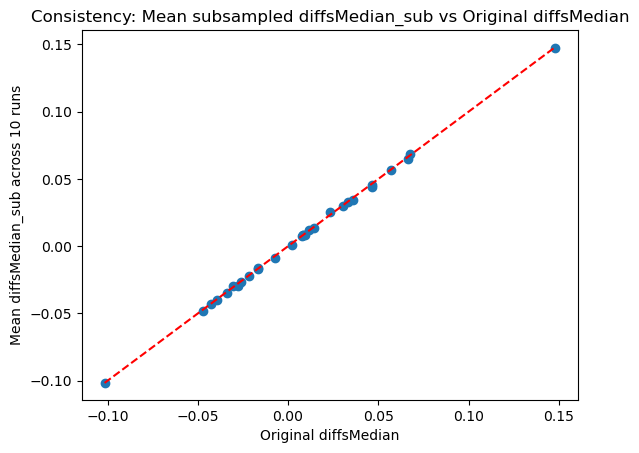

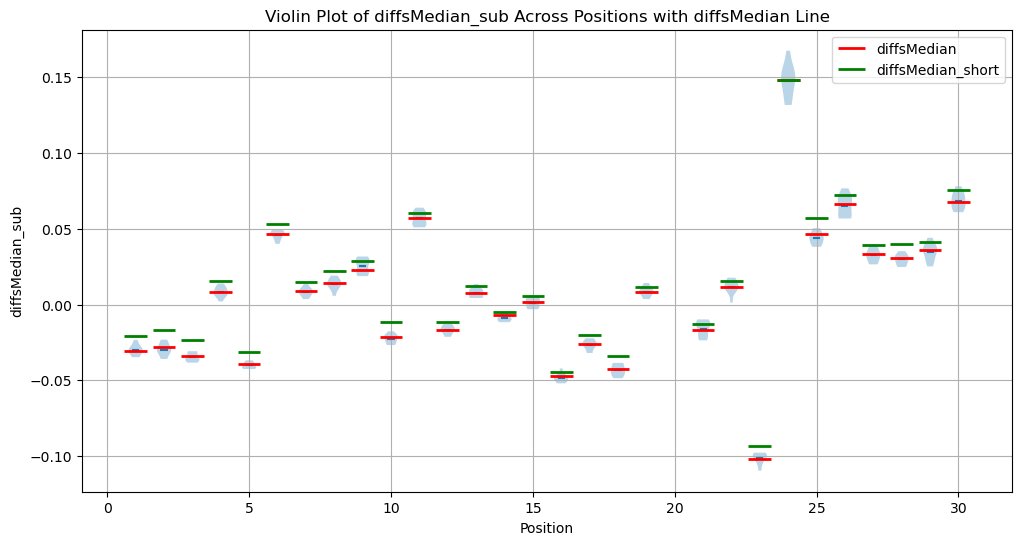

In [67]:
import random
import numpy as np

import matplotlib.pyplot as plt

positions = df[df['position'] != -1]['position'].unique()
origPred = df[df['position'] == -1]['prediction'].values[0]

all_diffsMedian_sub = []

for run in range(10):
    sampled_tokenIDs = random.sample(range(tokenizer.vocab_size), 200)
    tmp = df[df['new_token'].isin(sampled_tokenIDs + [4])]
    diffs_sub = []
    diffsMedian_sub = []
    origZs_sub = []
    valZs_sub = []
    scoreList_sub = []
    for pos in positions:
        scoreList_sub.append(scores[pos])
        subset = tmp[tmp['position'] == pos]
        val = subset[subset['new_token'] == 4]['prediction'].values[0]
        mean = subset['prediction'].mean()
        median = subset['prediction'].median()
        std = subset['prediction'].std()
        z_orig = (origPred - mean) / std
        z_val = (val - mean) / std
        diffs_sub.append(origPred - mean)
        diffsMedian_sub.append(origPred - median)
        origZs_sub.append(z_orig)
        valZs_sub.append(z_val)
        # Removed plotting inside loop to avoid 290 figures; can add back if needed
    all_diffsMedian_sub.append(diffsMedian_sub)

# Analyze consistency
correlations = []
for d in all_diffsMedian_sub:
    corr = np.corrcoef(diffsMedian, d)[0, 1]
    correlations.append(corr)

print("Correlations between each run's diffsMedian_sub and original diffsMedian:", correlations)
print("Mean correlation:", np.mean(correlations))
print("Std of correlations:", np.std(correlations))

# Plot the average diffsMedian_sub vs original diffsMedian
mean_diffsMedian_sub = np.mean(all_diffsMedian_sub, axis=0)
plt.figure()
plt.scatter(diffsMedian, mean_diffsMedian_sub)
plt.xlabel('Original diffsMedian')
plt.ylabel('Mean diffsMedian_sub across 10 runs')
plt.title('Consistency: Mean subsampled diffsMedian_sub vs Original diffsMedian')
plt.plot([min(diffsMedian), max(diffsMedian)], [min(diffsMedian), max(diffsMedian)], 'r--')  # diagonal line
plt.show()

# Create violin plot for diffsMedian_sub across positions
import matplotlib.pyplot as plt

# Prepare data for violin plot: list of lists, one per position
violin_data = [ [all_diffsMedian_sub[run][i] for run in range(10)] for i in range(len(positions)) ]

# Create the violin plot
plt.figure(figsize=(12, 6))
plt.violinplot(violin_data, positions=positions, showmeans=True, showmedians=False, showextrema=False)

# Add red horizontal lines for diffsMedian at each position
for i, pos in enumerate(positions):
    plt.hlines(diffsMedian[i], pos - 0.4, pos + 0.4, color='red', linewidth=2, label='diffsMedian' if i == 0 else "")# Add red horizontal lines for diffsMedian at each position
    plt.hlines(diffsMedian_short[i], pos - 0.4, pos + 0.4, color='green', linewidth=2, label='diffsMedian_short' if i == 0 else "")

# Labels and title
plt.xlabel('Position')
plt.ylabel('diffsMedian_sub')
plt.title('Violin Plot of diffsMedian_sub Across Positions with diffsMedian Line')
plt.legend()
plt.grid(True)
plt.show()

Correlations between each run's diffsMedian_sub and original diffsMedian: [0.9951578051428334, 0.995879871336841, 0.9972219962925553, 0.9963983528883382, 0.9984105657102513, 0.9941774709439997, 0.9960355702033469, 0.9971326239362182, 0.9966249559100414, 0.9961180386290414]
Mean correlation: 0.9963157250993468
Std of correlations: 0.0011045317597674132


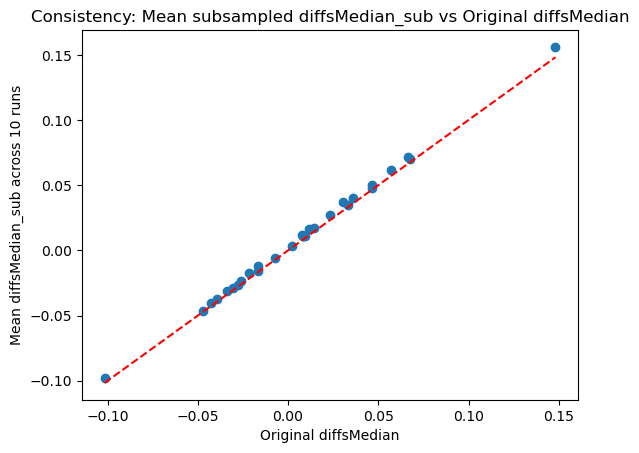

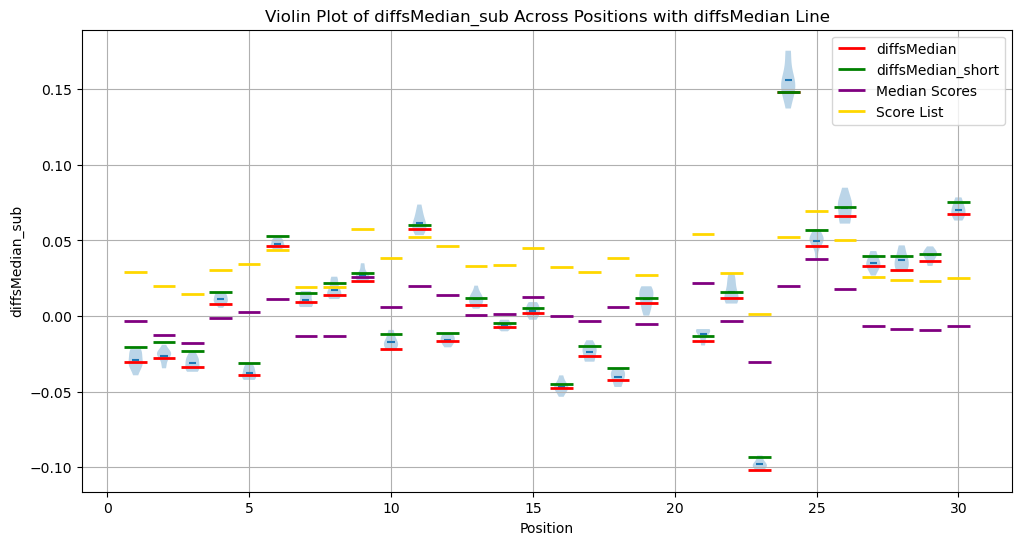

In [71]:
import random
import numpy as np

import matplotlib.pyplot as plt

positions = df[df['position'] != -1]['position'].unique()
origPred = df[df['position'] == -1]['prediction'].values[0]

all_diffsMedian_sub = []

for run in range(10):
    sampled_tokenIDs = random.sample(range(tokenizer.vocab_size), 100)
    tmp = df[df['new_token'].isin(sampled_tokenIDs + [4])]
    diffs_sub = []
    diffsMedian_sub = []
    origZs_sub = []
    valZs_sub = []
    scoreList_sub = []
    for pos in positions:
        scoreList_sub.append(scores[pos])
        subset = tmp[tmp['position'] == pos]
        val = subset[subset['new_token'] == 4]['prediction'].values[0]
        mean = subset['prediction'].mean()
        median = subset['prediction'].median()
        std = subset['prediction'].std()
        z_orig = (origPred - mean) / std
        z_val = (val - mean) / std
        diffs_sub.append(origPred - mean)
        diffsMedian_sub.append(origPred - median)
        origZs_sub.append(z_orig)
        valZs_sub.append(z_val)
        # Removed plotting inside loop to avoid 290 figures; can add back if needed
    all_diffsMedian_sub.append(diffsMedian_sub)

# Analyze consistency
correlations = []
for d in all_diffsMedian_sub:
    corr = np.corrcoef(diffsMedian, d)[0, 1]
    correlations.append(corr)

print("Correlations between each run's diffsMedian_sub and original diffsMedian:", correlations)
print("Mean correlation:", np.mean(correlations))
print("Std of correlations:", np.std(correlations))

# Plot the average diffsMedian_sub vs original diffsMedian
mean_diffsMedian_sub = np.mean(all_diffsMedian_sub, axis=0)
plt.figure()
plt.scatter(diffsMedian, mean_diffsMedian_sub)
plt.xlabel('Original diffsMedian')
plt.ylabel('Mean diffsMedian_sub across 10 runs')
plt.title('Consistency: Mean subsampled diffsMedian_sub vs Original diffsMedian')
plt.plot([min(diffsMedian), max(diffsMedian)], [min(diffsMedian), max(diffsMedian)], 'r--')  # diagonal line
plt.show()

# Create violin plot for diffsMedian_sub across positions
import matplotlib.pyplot as plt

# Prepare data for violin plot: list of lists, one per position
violin_data = [ [all_diffsMedian_sub[run][i] for run in range(10)] for i in range(len(positions)) ]

# Create the violin plot
plt.figure(figsize=(12, 6))
plt.violinplot(violin_data, positions=positions, showmeans=True, showmedians=False, showextrema=False)

# Add red horizontal lines for diffsMedian at each position
medianScores = np.median(scoreList_sub)
medianScores = [x-medianScores for x in scoreList_sub]
for i, pos in enumerate(positions):
    plt.hlines(diffsMedian[i], pos - 0.4, pos + 0.4, color='red', linewidth=2, label='diffsMedian' if i == 0 else "")# Add red horizontal lines for diffsMedian at each position
    plt.hlines(diffsMedian_short[i], pos - 0.4, pos + 0.4, color='green', linewidth=2, label='diffsMedian_short' if i == 0 else "")
    plt.hlines(medianScores[i], pos - 0.4, pos + 0.4, color='purple', linewidth=2, label='Median Scores' if i == 0 else "")
    plt.hlines(scoreList_sub[i], pos - 0.4, pos + 0.4, color='gold', linewidth=2, label='Score List' if i == 0 else "")

# Labels and title
plt.xlabel('Position')
plt.ylabel('diffsMedian_sub')
plt.title('Violin Plot of diffsMedian_sub Across Positions with diffsMedian Line')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(scoreList, diffsMedian)
plt.xlabel('Score')
plt.ylabel('Diffs Median')
plt.title('Scatter Plot of Score vs Diffs Median')
plt.show()